# Real100 UPGMA100 diagnostics: posterior 95% HPD + midpoint GP traces

This notebook reads the outcome files produced by the four UPGMA100 jobs:

1. **RI-BM**
2. **DIS-BM**
3. **RI-SE**
4. **DIS-SE**

For every parameter setting that appears in the uploaded SLURM files, it produces **two figures in this order**:

1. post-burn-in traceplot of the latent Gaussian-process value at grid index `50`;
2. posterior median with the **95% HPD lower and upper limits**, plus UPGMA100 coalescent events shown as vertical `|` rug marks along the time axis.

The outcome directory is:

`outputs/cell_lineage/`

Missing outcome files are skipped and reported rather than stopping the notebook.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RESULT_DIR = Path(
    "outputs/cell_lineage/"
)

FIGURE_DIR = RESULT_DIR / "diagnostic_figures"
SAVE_FIGURES = False

# Python 0-based index 50, matching chain[:, 50].
MID_IDX = 50

# Plotting 1,000,000 points for every setting is very heavy.
# This only thins the displayed trace; it does not change stored chains.
# Set to None to draw every post-burn-in saved point.
TRACE_MAX_POINTS = 100_000

if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("RESULT_DIR =", RESULT_DIR)
print("MID_IDX =", MID_IDX)
print("SAVE_FIGURES =", SAVE_FIGURES)


RESULT_DIR = [historical output directory]
MID_IDX = 50
SAVE_FIGURES = False


## Parameter grids from the uploaded SLURM files

The uploaded SLURMs use:

- RI-BM: `const = 0.1, 0.5, 1, 5`; `nsim1=nsim2 = 1,000,000, 2,000,000, 3,000,000, 5,000,000`
- DIS-BM: `const = 0.1, 0.5, 1, 5`; `nsim1=nsim2 = 100,000, 200,000, 300,000, 500,000`
- RI-SE and DIS-SE: 11 proposal step sizes × `nsim1=nsim2 = 100,000, 200,000, 300,000, 500,000`

The notebook follows those files exactly.

In [2]:
CONST_VALUES = [0.1, 0.5, 1.0, 5.0]

RI_BM_NSIM_VALUES = [
    1_000_000,
    2_000_000,
    3_000_000,
    5_000_000,
]

DIS_BM_NSIM_VALUES = [
    100_000,
    200_000,
    300_000,
    500_000,
]

SE_PROPOSAL_VALUES = [
    5e-6,
    5e-5,
    5e-4,
    1e-3,
    5e-3,
    5e-2,
    1e-2,
    0.1,
    0.15,
    0.2,
    0.3,
]

SE_NSIM_VALUES = [
    100_000,
    200_000,
    300_000,
    500_000,
]

print("RI-BM settings :", len(CONST_VALUES) * len(RI_BM_NSIM_VALUES))
print("DIS-BM settings:", len(CONST_VALUES) * len(DIS_BM_NSIM_VALUES))
print("RI-SE settings :", len(SE_PROPOSAL_VALUES) * len(SE_NSIM_VALUES))
print("DIS-SE settings:", len(SE_PROPOSAL_VALUES) * len(SE_NSIM_VALUES))
print("TOTAL settings :", (
    len(CONST_VALUES) * len(RI_BM_NSIM_VALUES)
    + len(CONST_VALUES) * len(DIS_BM_NSIM_VALUES)
    + 2 * len(SE_PROPOSAL_VALUES) * len(SE_NSIM_VALUES)
))


RI-BM settings : 16
DIS-BM settings: 16
RI-SE settings : 44
DIS-SE settings: 44
TOTAL settings : 120


In [3]:
def bm_num_tag(x):
    s = f"{x:.12g}"
    s = s.replace("e-0", "e-").replace("e+0", "e+")
    return s.replace(".", "p").replace("+", "")


def se_num_tag(x):
    s = f"{x:.12g}"
    s = s.replace("e-0", "e-").replace("e+0", "e+")
    return s


def result_path(method, const=None, proposal=None, nsim=None):
    if method == "RI_BM":
        return RESULT_DIR / (
            f"real100_BM_RI_const_{bm_num_tag(const)}"
            f"_nsim1_{nsim}_nsim2_{nsim}.npz"
        )

    if method == "DIS_BM":
        return RESULT_DIR / (
            f"real100_BM_DIS_const_{bm_num_tag(const)}"
            f"_nsim1_{nsim}_nsim2_{nsim}.npz"
        )

    if method == "RI_SE":
        return RESULT_DIR / (
            f"real100_SE_RI_stepsize_{se_num_tag(proposal)}"
            f"_nsim1_{nsim}_nsim2_{nsim}.npz"
        )

    if method == "DIS_SE":
        return RESULT_DIR / (
            f"real100_SE_DIS_stepsize_{se_num_tag(proposal)}"
            f"_nsim1_{nsim}_nsim2_{nsim}.npz"
        )

    raise ValueError(f"Unknown method: {method}")


print(result_path("RI_BM", const=0.1, nsim=RI_BM_NSIM_VALUES[0]))
print(result_path("DIS_BM", const=0.1, nsim=DIS_BM_NSIM_VALUES[0]))
print(result_path("RI_SE", proposal=5e-6, nsim=100_000))
print(result_path("DIS_SE", proposal=5e-6, nsim=100_000))


[historical output directory]/real100_BM_RI_const_0p1_nsim1_1000000_nsim2_1000000.npz
[historical output directory]/real100_BM_DIS_const_0p1_nsim1_100000_nsim2_100000.npz
[historical output directory]/real100_SE_RI_stepsize_5e-6_nsim1_100000_nsim2_100000.npz
[historical output directory]/real100_SE_DIS_stepsize_5e-6_nsim1_100000_nsim2_100000.npz


In [4]:
def read_real100_result(path, method):
    """
    Read posterior summaries and construct the post-burn-in
    latent-GP trace at grid index MID_IDX.
    """
    with np.load(path, allow_pickle=True) as z:
        nsim1 = int(np.asarray(z["nsim1"]).item())
        nsim2 = int(np.asarray(z["nsim2"]).item())
        rem = int(np.asarray(z["rem"]).item()) if "rem" in z.files else 1

        med = np.asarray(z["med"], dtype=float).squeeze()
        low = np.asarray(z["low"], dtype=float).squeeze()
        high = np.asarray(z["high"], dtype=float).squeeze()

        # UPGMA100 coalescent/event times saved by all four methods.
        events = np.asarray(z["c"], dtype=float).squeeze()

        if "d" in z.files:
            loc = np.asarray(z["d"], dtype=float).squeeze()
        elif "loc" in z.files:
            loc = np.asarray(z["loc"], dtype=float).squeeze()
        else:
            raise KeyError(f"No d/loc grid found in {path}")

        if MID_IDX >= len(loc):
            raise IndexError(
                f"MID_IDX={MID_IDX} is outside a grid of length {len(loc)}"
            )

        # RI outputs save N_e in aa, so latent GP = 1 / N_e.
        if method == "RI_BM":
            ne_chain = np.asarray(z["aa"], dtype=float)
            burn_saved = nsim1 // rem
            trace = 1.0 / ne_chain[burn_saved:, MID_IDX]
            iterations = nsim1 + rem * np.arange(len(trace))

        elif method == "RI_SE":
            ne_chain = np.asarray(z["aa"], dtype=float)
            trace = 1.0 / ne_chain[nsim1:, MID_IDX]
            iterations = nsim1 + np.arange(len(trace))

        # DIS outputs save the latent GP directly in g_mk_list.
        elif method in ("DIS_BM", "DIS_SE"):
            g_chain = np.asarray(z["g_mk_list"], dtype=float)
            trace = g_chain[nsim1:, MID_IDX]
            iterations = nsim1 + np.arange(len(trace))

        else:
            raise ValueError(f"Unknown method: {method}")

    midpoint_time = float(loc[MID_IDX])

    return {
        "loc": loc,
        "med": med,
        "low": low,
        "high": high,
        "events": events,
        "trace": trace,
        "iterations": iterations,
        "midpoint_time": midpoint_time,
        "nsim1": nsim1,
        "nsim2": nsim2,
        "rem": rem,
    }


def display_trace_subset(iterations, trace):
    if TRACE_MAX_POINTS is None or len(trace) <= TRACE_MAX_POINTS:
        return iterations, trace, 1

    stride = int(np.ceil(len(trace) / TRACE_MAX_POINTS))
    return iterations[::stride], trace[::stride], stride


In [5]:
def setting_label(method, const=None, proposal=None, nsim=None):
    if method in ("RI_BM", "DIS_BM"):
        return f"{method}: const={const:g}, nsim1=nsim2={nsim}"

    return (
        f"{method}: stepsize={proposal:g}, "
        f"nsim1=nsim2={nsim}"
    )


def safe_filename(text):
    return (
        text.replace(" ", "_")
            .replace("=", "")
            .replace(",", "")
            .replace(":", "")
            .replace(".", "p")
    )


def plot_one_setting(method, const=None, proposal=None, nsim=None):
    path = result_path(
        method,
        const=const,
        proposal=proposal,
        nsim=nsim,
    )

    label = setting_label(
        method,
        const=const,
        proposal=proposal,
        nsim=nsim,
    )

    print("\n" + "=" * 90)
    print(label)
    print(path)

    if not path.exists():
        print("MISSING -> skipped")
        return False

    result = read_real100_result(path, method)

    # --------------------------------------------------------
    # 1. Traceplot first
    # --------------------------------------------------------
    xtrace, ytrace, stride = display_trace_subset(
        result["iterations"],
        result["trace"],
    )

    fig = plt.figure(figsize=(12, 4))
    plt.plot(xtrace, ytrace, linewidth=0.5)
    plt.xlabel("Original MCMC iteration")
    plt.ylabel("Latent GP at index 50")
    plt.title(
        f"{label}\n"
        f"Post-burn-in midpoint GP trace: index 50, "
        f"t={result['midpoint_time']:.4g}"
    )

    if stride > 1:
        plt.figtext(
            0.5,
            0.01,
            f"Display only: every {stride}th saved point is drawn; "
            f"the stored chain is unchanged.",
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(
            FIGURE_DIR / (safe_filename(label) + "_midpoint_GP_trace.pdf"),
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)

    # --------------------------------------------------------
    # 2. Posterior median + 95% HPD
    # --------------------------------------------------------
    loc = result["loc"]
    med = result["med"]
    low = result["low"]
    high = result["high"]
    events = result["events"]

    fig = plt.figure(figsize=(8, 5))

    if method.startswith("DIS"):
        # Piecewise-constant visualization for discretized methods.
        xplot = np.r_[0.0, loc]
        plt.step(
            xplot,
            np.r_[med[0], med],
            where="post",
            label="Posterior median",
        )
        plt.step(
            xplot,
            np.r_[low[0], low],
            where="post",
            label="95% HPD lower",
        )
        plt.step(
            xplot,
            np.r_[high[0], high],
            where="post",
            label="95% HPD upper",
        )
    else:
        plt.plot(loc, med, label="Posterior median")
        plt.plot(loc, low, label="95% HPD lower")
        plt.plot(loc, high, label="95% HPD upper")

    # --------------------------------------------------------
    # UPGMA100 event rug: vertical "|" marks along the bottom.
    # Use an axis-coordinate transform so the marks stay at the
    # bottom regardless of the posterior y-axis range.
    # --------------------------------------------------------
    ax = plt.gca()
    ax.plot(
        events,
        np.full_like(events, 0.02, dtype=float),
        linestyle="None",
        marker="|",
        markersize=8,
        markeredgewidth=0.8,
        transform=ax.get_xaxis_transform(),
        clip_on=False,
        label="Coalescent events",
    )

    plt.xlabel("Time")
    plt.ylabel(r"$N_e(t)$")
    plt.title(label + "\nPosterior median and 95% HPD limits + events")
    plt.legend()
    plt.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(
            FIGURE_DIR / (safe_filename(label) + "_posterior_median_HPD.pdf"),
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)

    return True


## RI-BM: all 16 settings


RI_BM: const=0.1, nsim1=nsim2=1000000
[historical output directory]/real100_BM_RI_const_0p1_nsim1_1000000_nsim2_1000000.npz


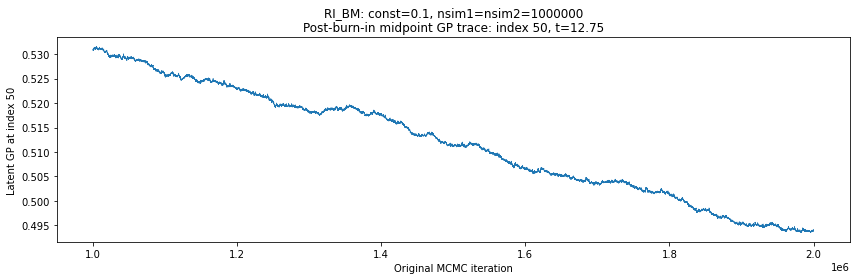

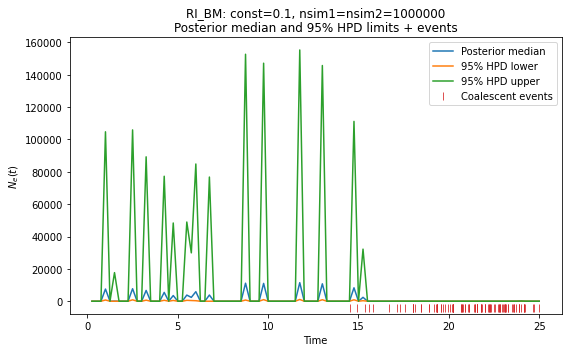


RI_BM: const=0.5, nsim1=nsim2=1000000
[historical output directory]/real100_BM_RI_const_0p5_nsim1_1000000_nsim2_1000000.npz


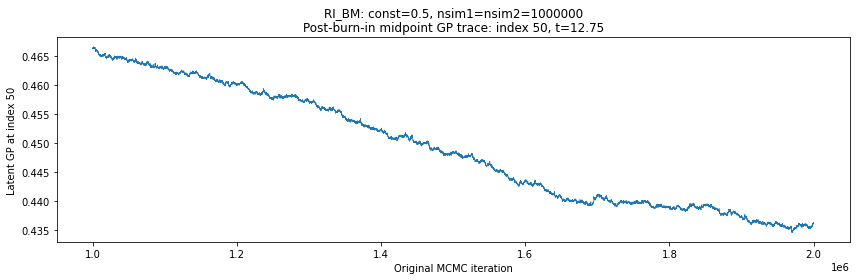

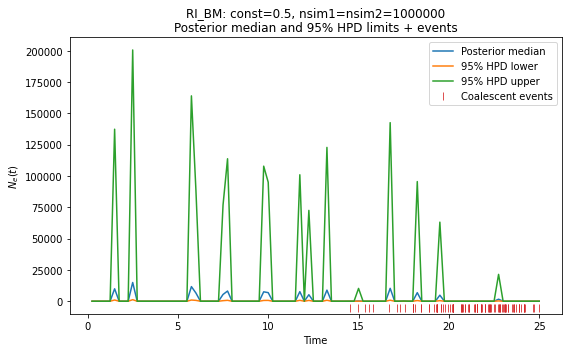


RI_BM: const=1, nsim1=nsim2=1000000
[historical output directory]/real100_BM_RI_const_1_nsim1_1000000_nsim2_1000000.npz


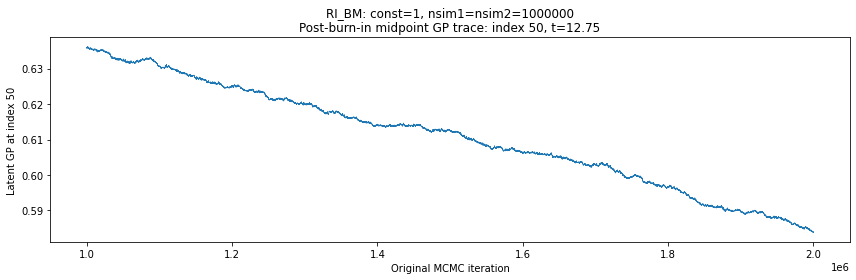

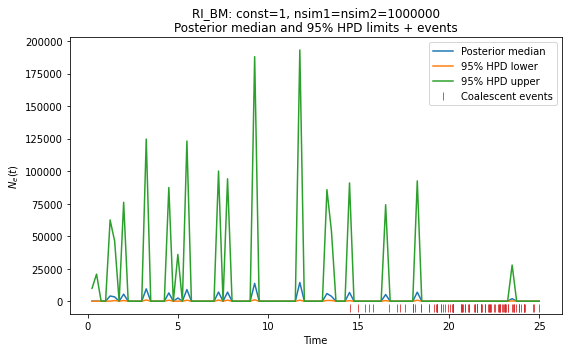


RI_BM: const=5, nsim1=nsim2=1000000
[historical output directory]/real100_BM_RI_const_5_nsim1_1000000_nsim2_1000000.npz


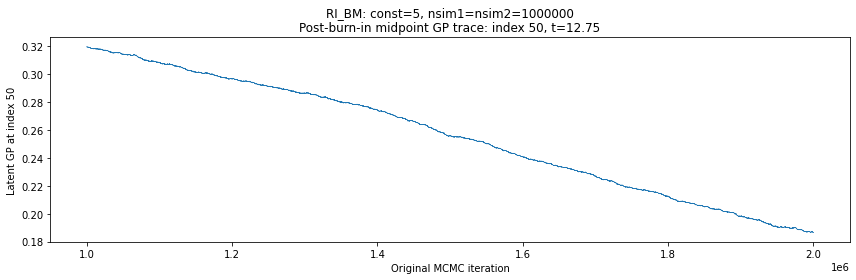

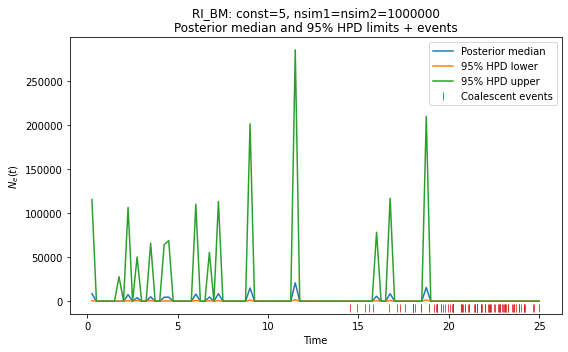


RI_BM: const=0.1, nsim1=nsim2=2000000
[historical output directory]/real100_BM_RI_const_0p1_nsim1_2000000_nsim2_2000000.npz


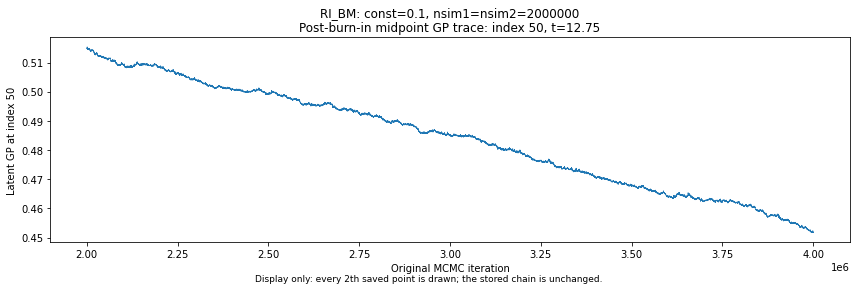

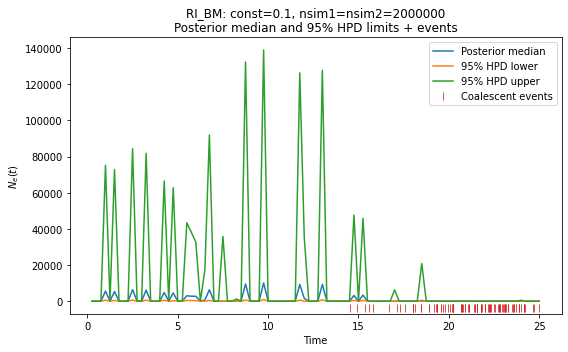


RI_BM: const=0.5, nsim1=nsim2=2000000
[historical output directory]/real100_BM_RI_const_0p5_nsim1_2000000_nsim2_2000000.npz


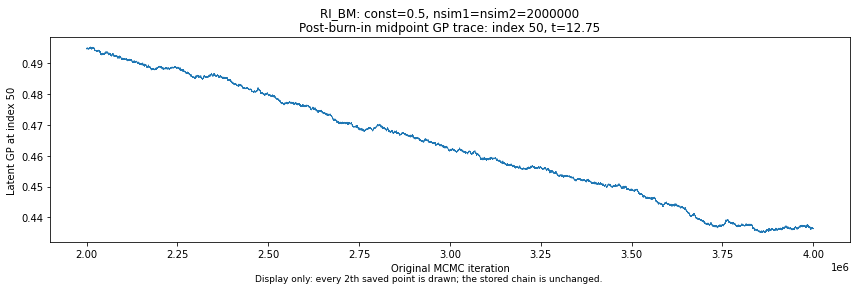

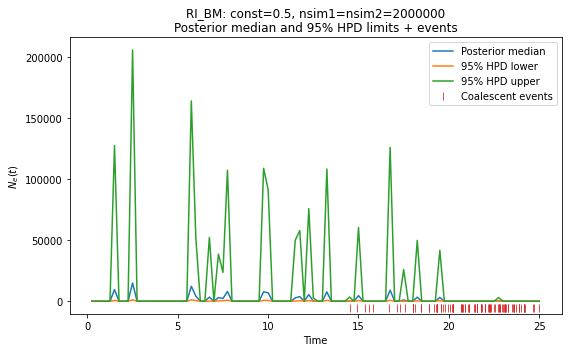


RI_BM: const=1, nsim1=nsim2=2000000
[historical output directory]/real100_BM_RI_const_1_nsim1_2000000_nsim2_2000000.npz


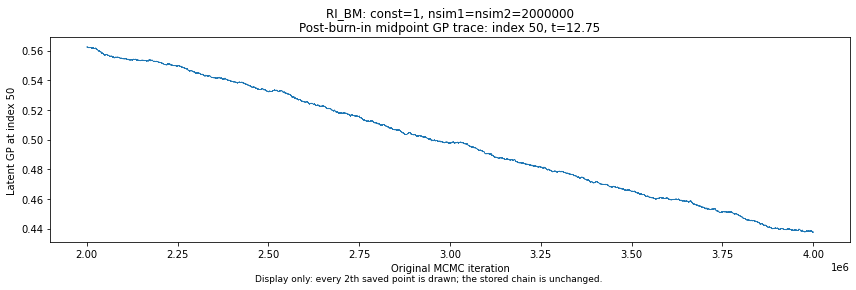

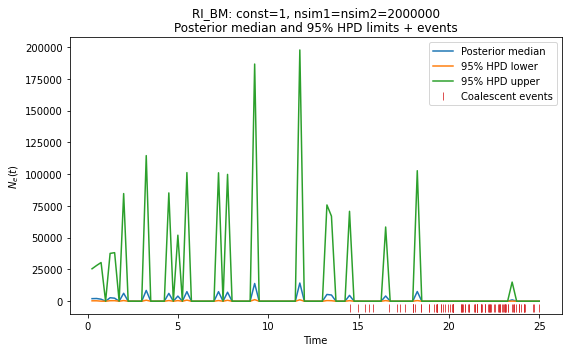


RI_BM: const=5, nsim1=nsim2=2000000
[historical output directory]/real100_BM_RI_const_5_nsim1_2000000_nsim2_2000000.npz


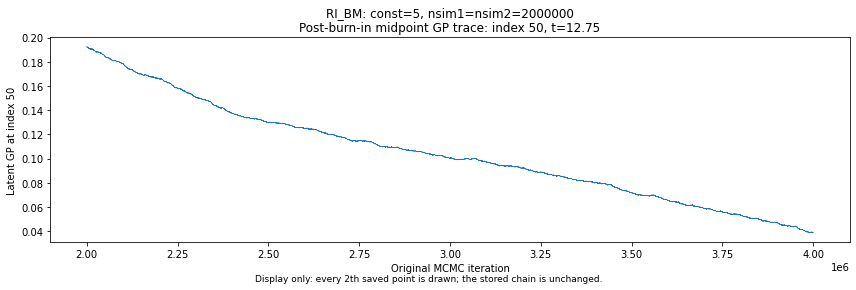

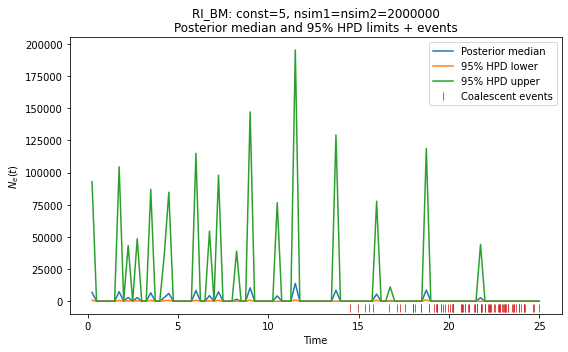


RI_BM: const=0.1, nsim1=nsim2=3000000
[historical output directory]/real100_BM_RI_const_0p1_nsim1_3000000_nsim2_3000000.npz


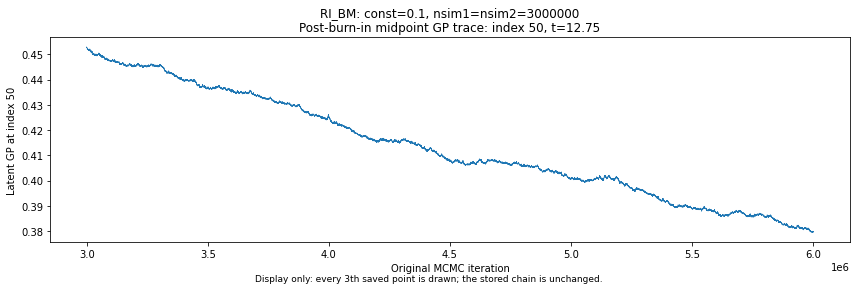

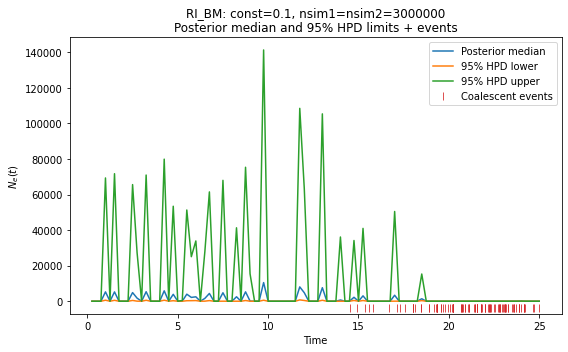


RI_BM: const=0.5, nsim1=nsim2=3000000
[historical output directory]/real100_BM_RI_const_0p5_nsim1_3000000_nsim2_3000000.npz


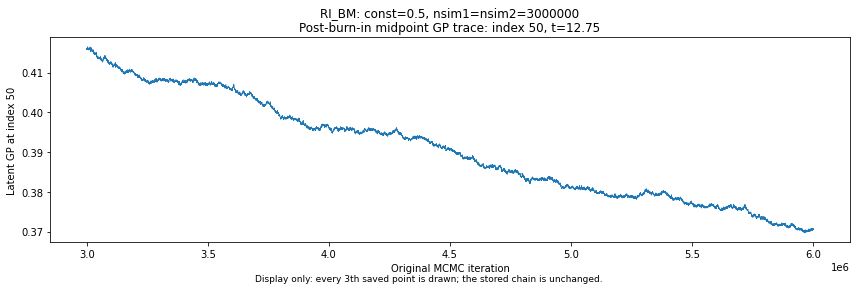

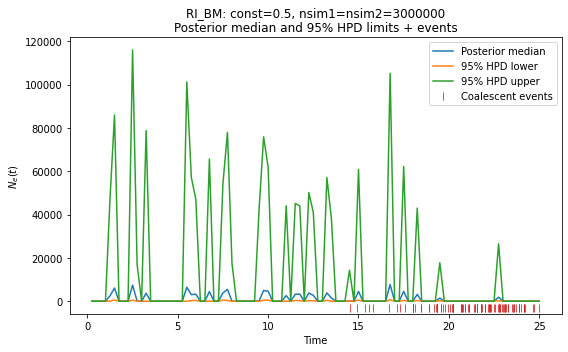


RI_BM: const=1, nsim1=nsim2=3000000
[historical output directory]/real100_BM_RI_const_1_nsim1_3000000_nsim2_3000000.npz


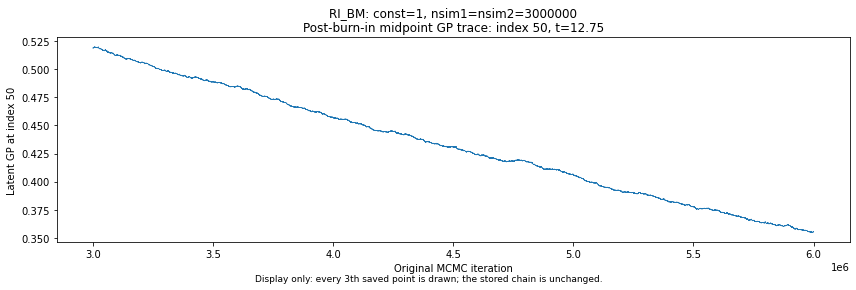

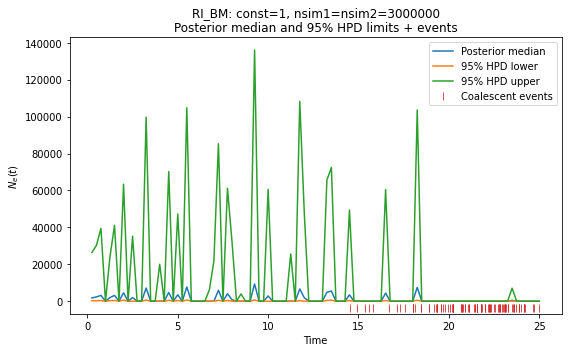


RI_BM: const=5, nsim1=nsim2=3000000
[historical output directory]/real100_BM_RI_const_5_nsim1_3000000_nsim2_3000000.npz


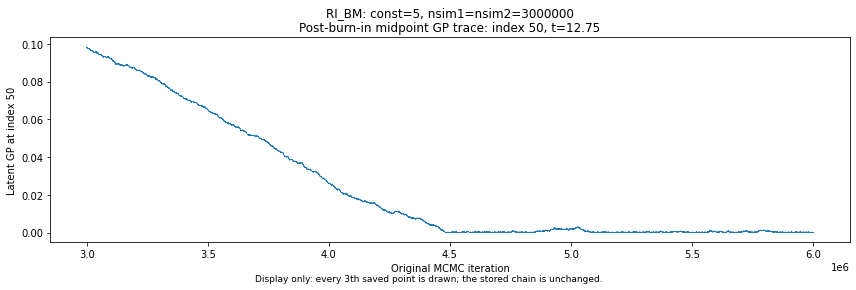

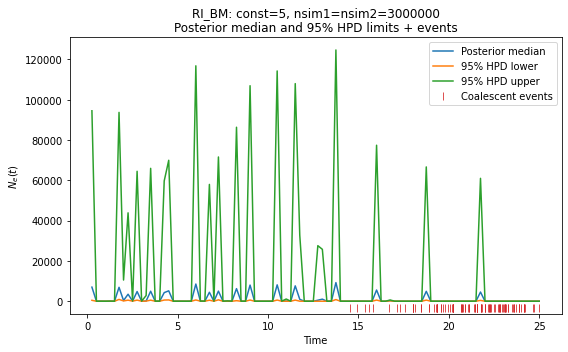


RI_BM: const=0.1, nsim1=nsim2=5000000
[historical output directory]/real100_BM_RI_const_0p1_nsim1_5000000_nsim2_5000000.npz


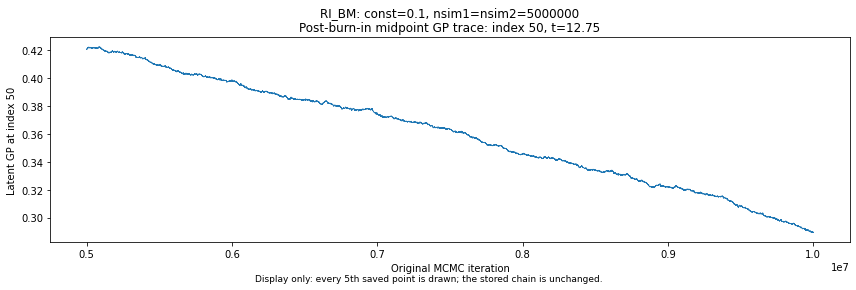

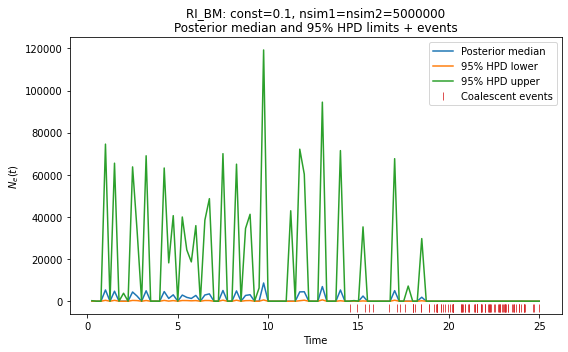


RI_BM: const=0.5, nsim1=nsim2=5000000
[historical output directory]/real100_BM_RI_const_0p5_nsim1_5000000_nsim2_5000000.npz


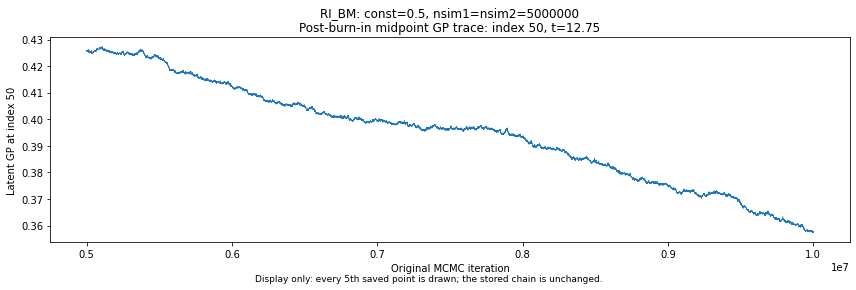

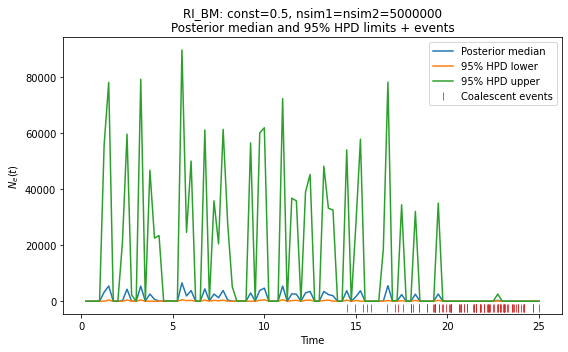


RI_BM: const=1, nsim1=nsim2=5000000
[historical output directory]/real100_BM_RI_const_1_nsim1_5000000_nsim2_5000000.npz


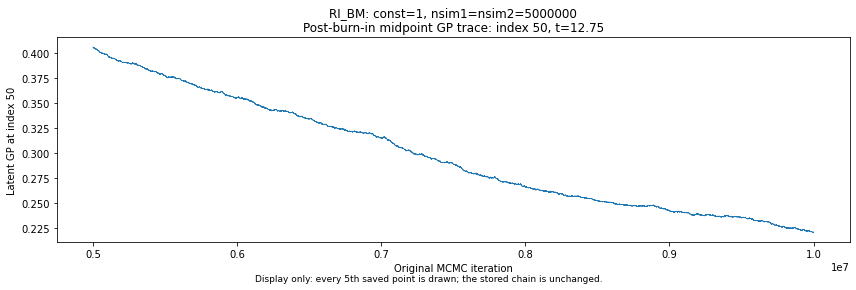

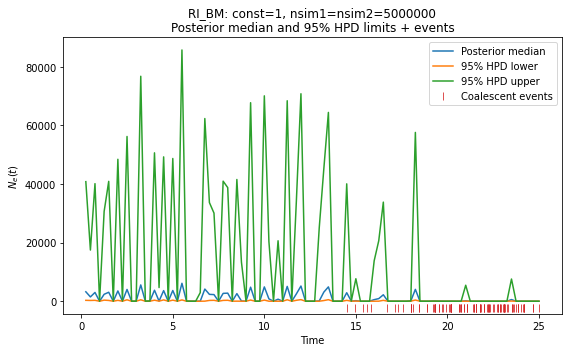


RI_BM: const=5, nsim1=nsim2=5000000
[historical output directory]/real100_BM_RI_const_5_nsim1_5000000_nsim2_5000000.npz
MISSING -> skipped

Missing RI-BM settings:
[(5.0, 5000000)]


In [6]:
missing_RI_BM = []

for nsim in RI_BM_NSIM_VALUES:
    for const in CONST_VALUES:
        ok = plot_one_setting(
            "RI_BM",
            const=const,
            nsim=nsim,
        )
        if not ok:
            missing_RI_BM.append((const, nsim))

print("\nMissing RI-BM settings:")
print(missing_RI_BM)


## DIS-BM: all 16 settings


DIS_BM: const=0.1, nsim1=nsim2=100000
[historical output directory]/real100_BM_DIS_const_0p1_nsim1_100000_nsim2_100000.npz


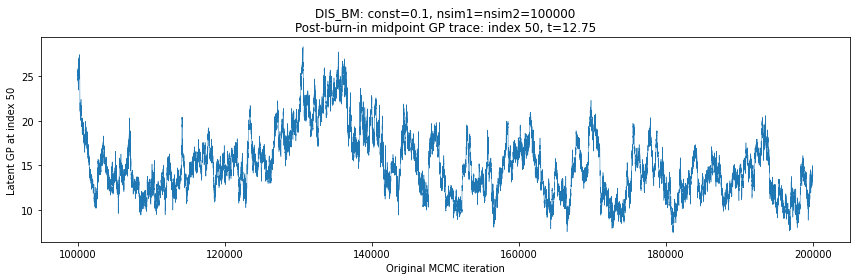

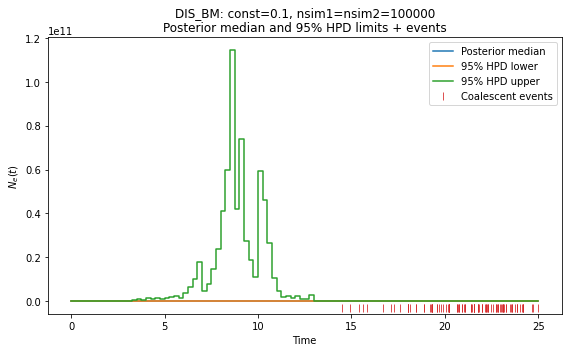


DIS_BM: const=0.5, nsim1=nsim2=100000
[historical output directory]/real100_BM_DIS_const_0p5_nsim1_100000_nsim2_100000.npz


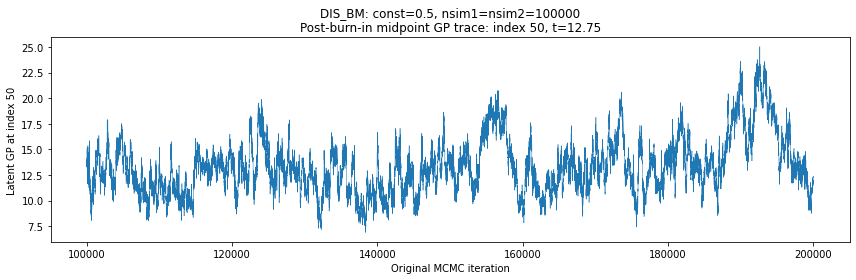

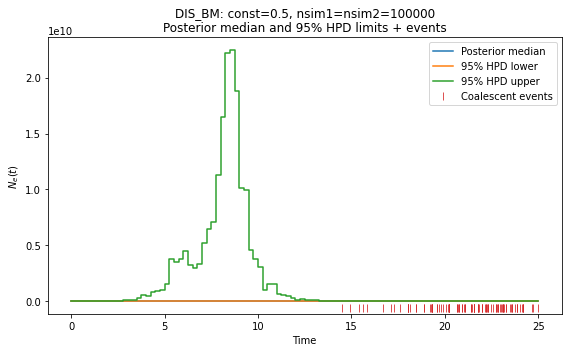


DIS_BM: const=1, nsim1=nsim2=100000
[historical output directory]/real100_BM_DIS_const_1_nsim1_100000_nsim2_100000.npz


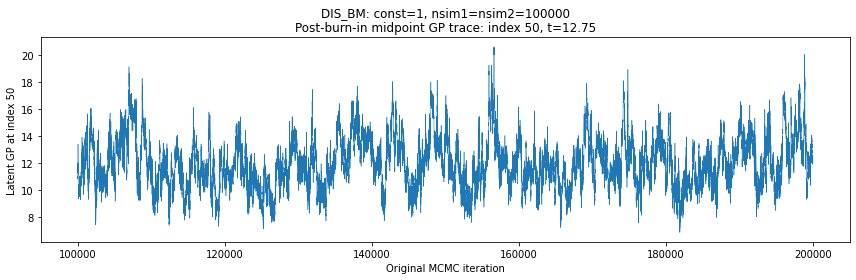

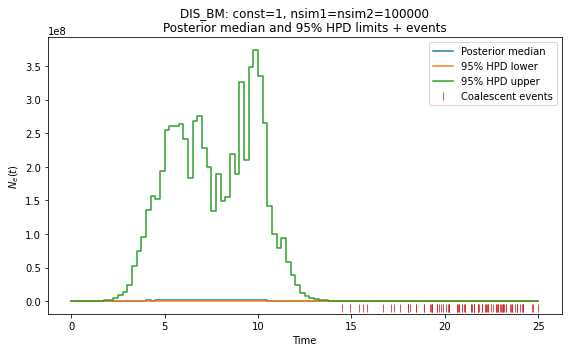


DIS_BM: const=5, nsim1=nsim2=100000
[historical output directory]/real100_BM_DIS_const_5_nsim1_100000_nsim2_100000.npz


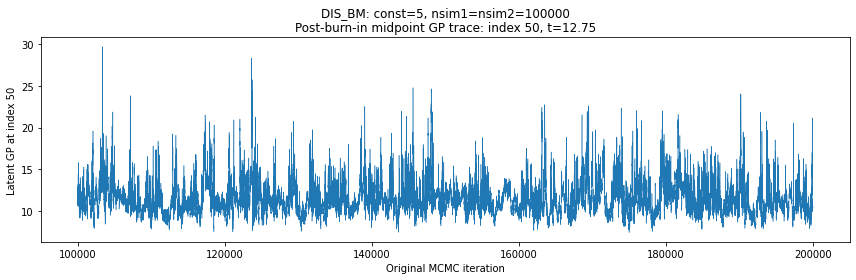

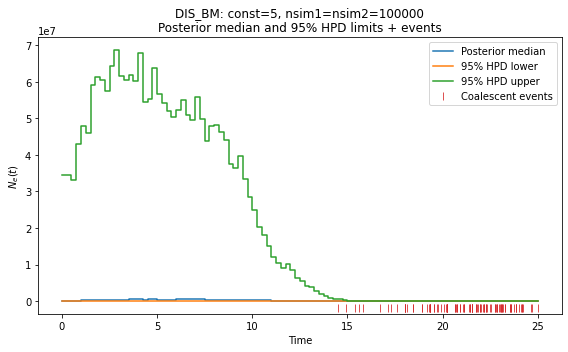


DIS_BM: const=0.1, nsim1=nsim2=200000
[historical output directory]/real100_BM_DIS_const_0p1_nsim1_200000_nsim2_200000.npz


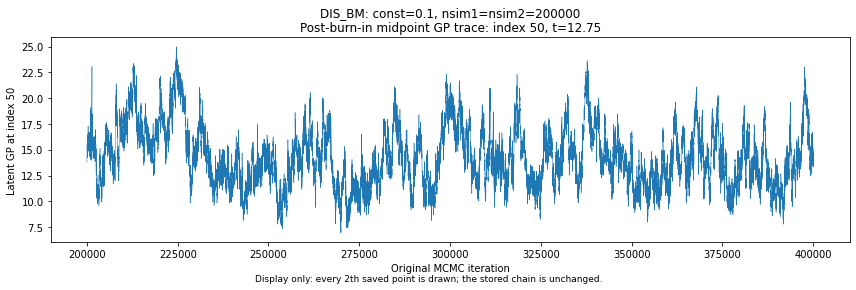

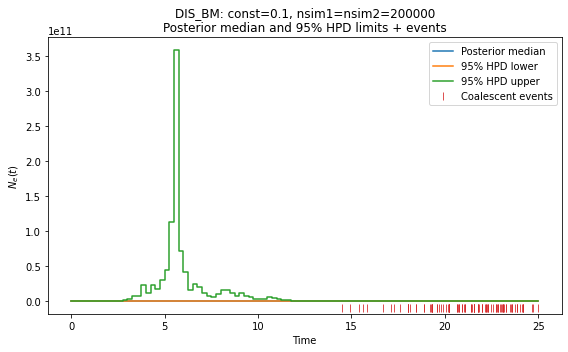


DIS_BM: const=0.5, nsim1=nsim2=200000
[historical output directory]/real100_BM_DIS_const_0p5_nsim1_200000_nsim2_200000.npz


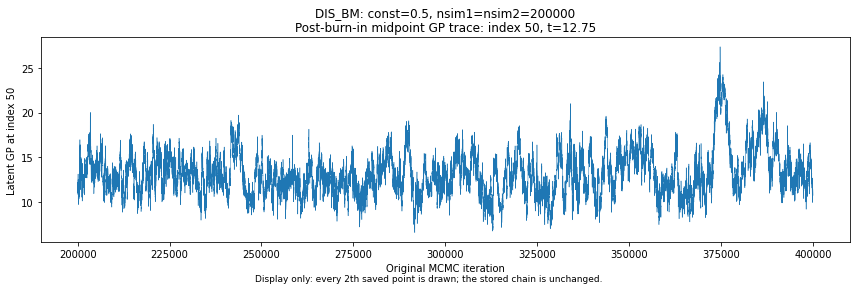

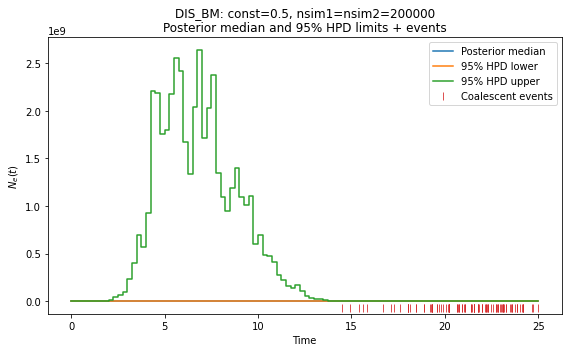


DIS_BM: const=1, nsim1=nsim2=200000
[historical output directory]/real100_BM_DIS_const_1_nsim1_200000_nsim2_200000.npz


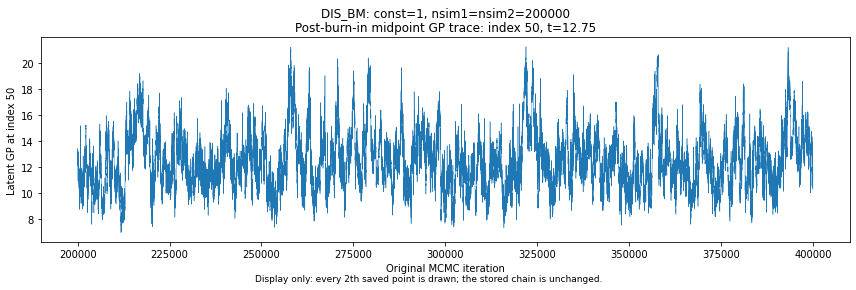

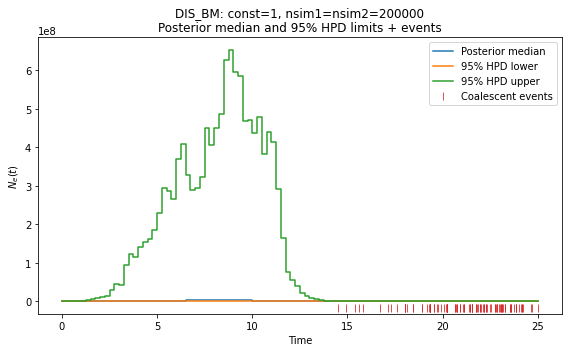


DIS_BM: const=5, nsim1=nsim2=200000
[historical output directory]/real100_BM_DIS_const_5_nsim1_200000_nsim2_200000.npz


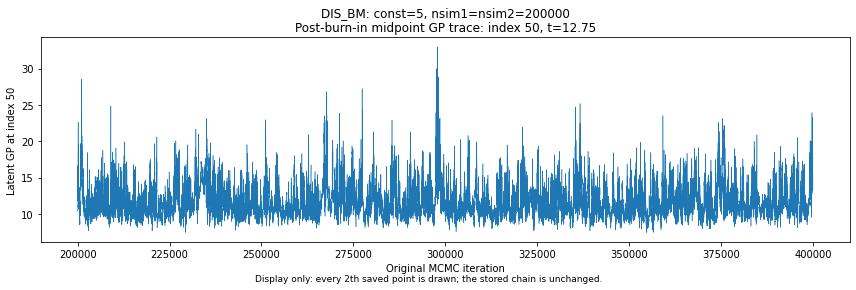

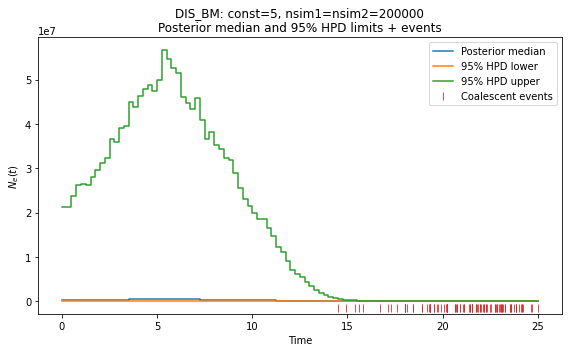


DIS_BM: const=0.1, nsim1=nsim2=300000
[historical output directory]/real100_BM_DIS_const_0p1_nsim1_300000_nsim2_300000.npz


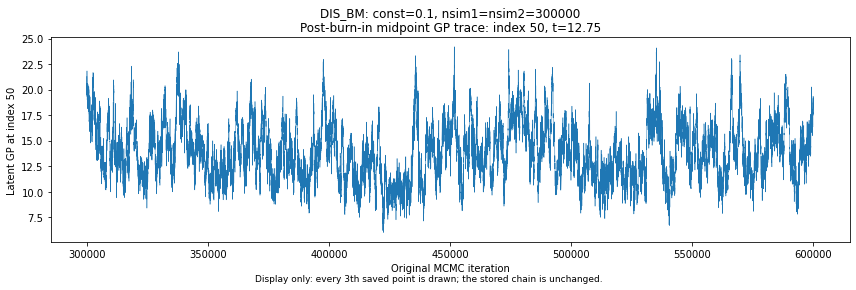

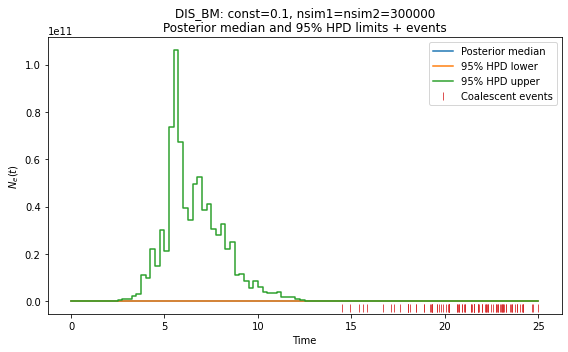


DIS_BM: const=0.5, nsim1=nsim2=300000
[historical output directory]/real100_BM_DIS_const_0p5_nsim1_300000_nsim2_300000.npz


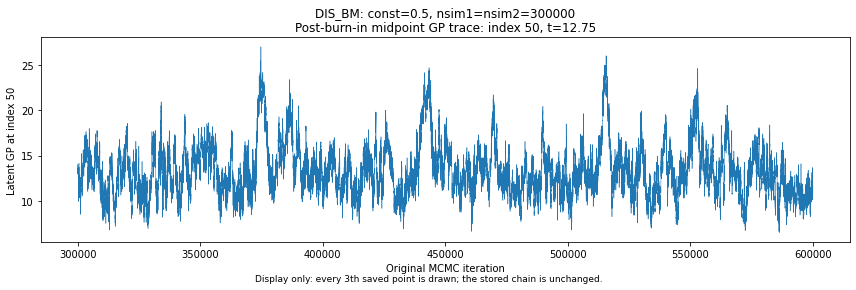

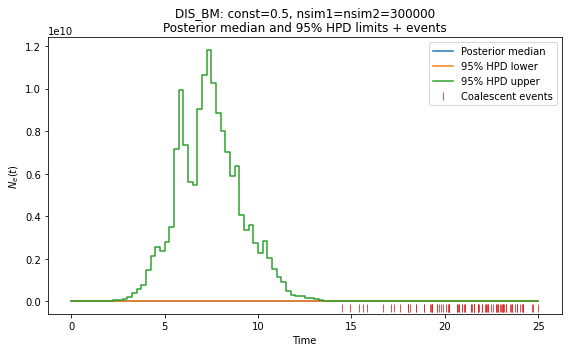


DIS_BM: const=1, nsim1=nsim2=300000
[historical output directory]/real100_BM_DIS_const_1_nsim1_300000_nsim2_300000.npz


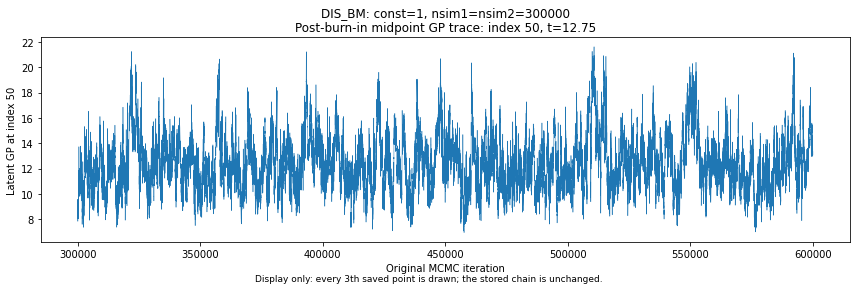

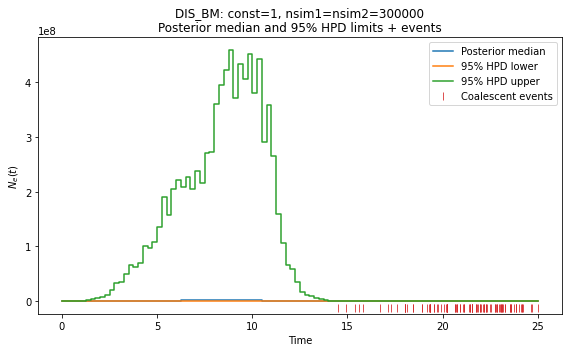


DIS_BM: const=5, nsim1=nsim2=300000
[historical output directory]/real100_BM_DIS_const_5_nsim1_300000_nsim2_300000.npz


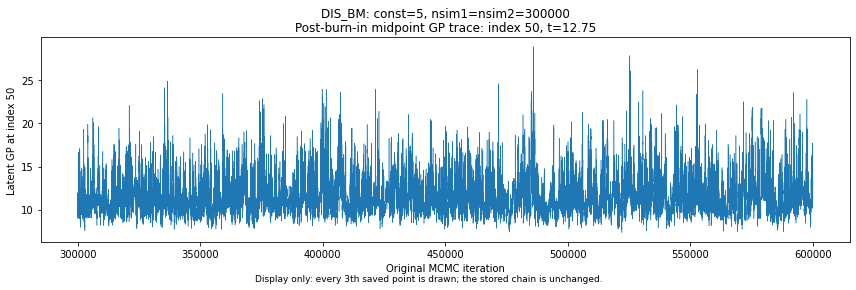

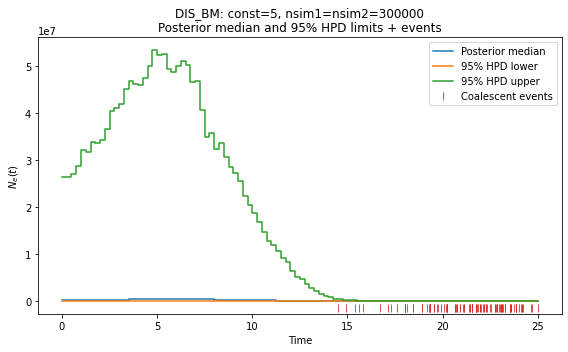


DIS_BM: const=0.1, nsim1=nsim2=500000
[historical output directory]/real100_BM_DIS_const_0p1_nsim1_500000_nsim2_500000.npz


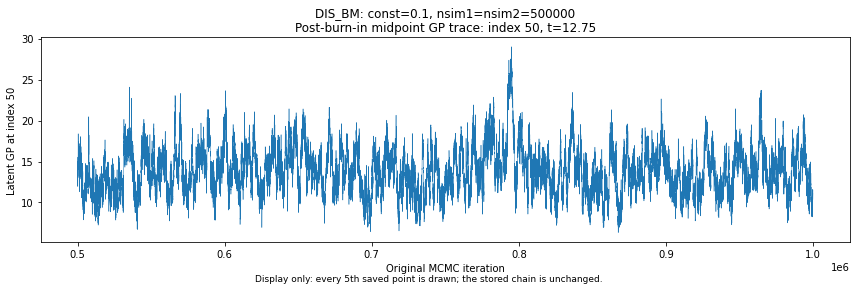

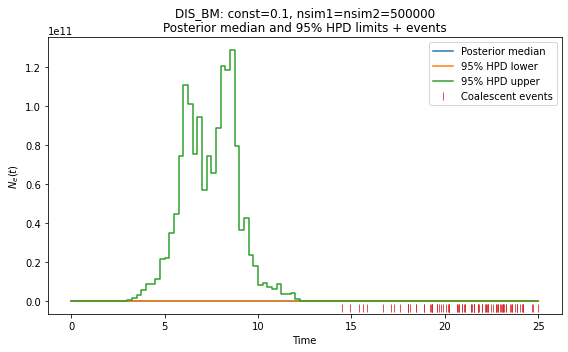


DIS_BM: const=0.5, nsim1=nsim2=500000
[historical output directory]/real100_BM_DIS_const_0p5_nsim1_500000_nsim2_500000.npz


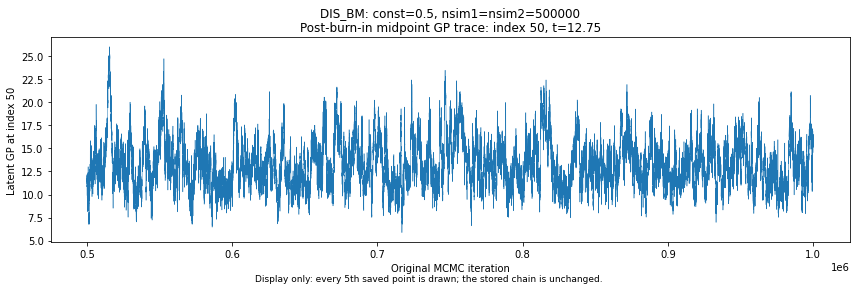

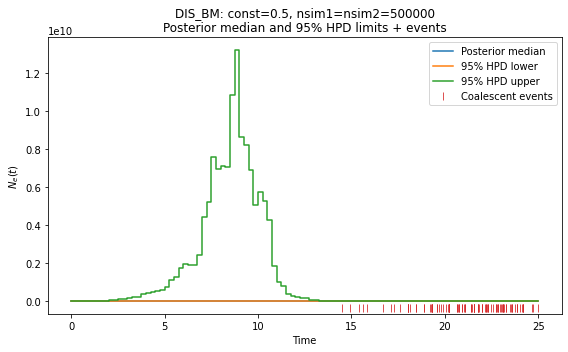


DIS_BM: const=1, nsim1=nsim2=500000
[historical output directory]/real100_BM_DIS_const_1_nsim1_500000_nsim2_500000.npz


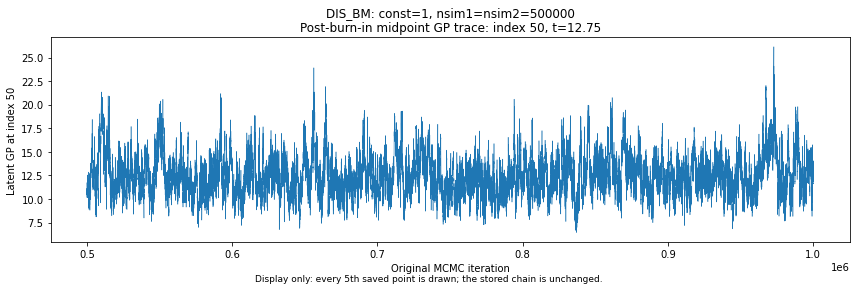

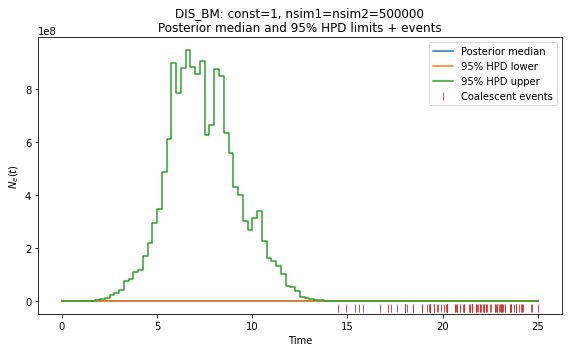


DIS_BM: const=5, nsim1=nsim2=500000
[historical output directory]/real100_BM_DIS_const_5_nsim1_500000_nsim2_500000.npz


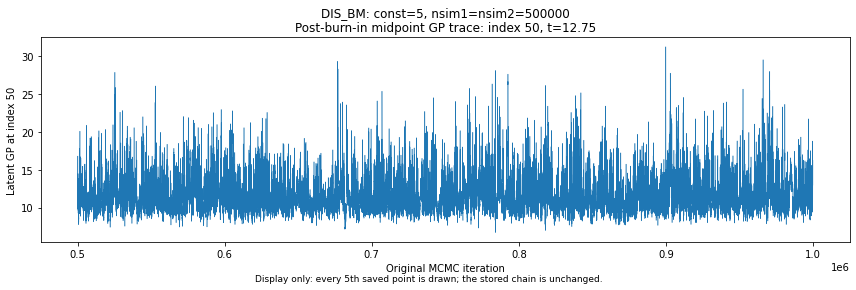

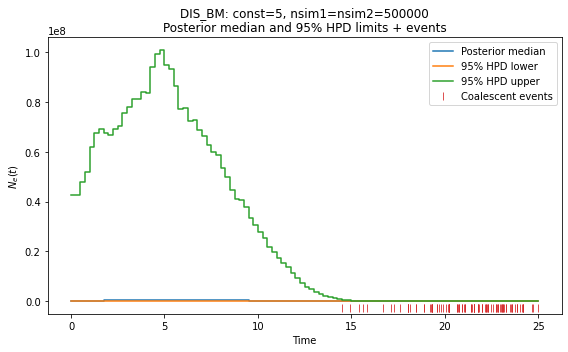


Missing DIS-BM settings:
[]


In [7]:
missing_DIS_BM = []

for nsim in DIS_BM_NSIM_VALUES:
    for const in CONST_VALUES:
        ok = plot_one_setting(
            "DIS_BM",
            const=const,
            nsim=nsim,
        )
        if not ok:
            missing_DIS_BM.append((const, nsim))

print("\nMissing DIS-BM settings:")
print(missing_DIS_BM)


## RI-SE: all 44 settings


RI_SE: stepsize=5e-06, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_5e-6_nsim1_100000_nsim2_100000.npz


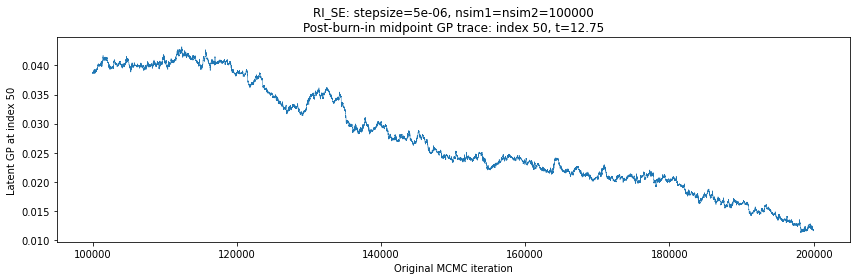

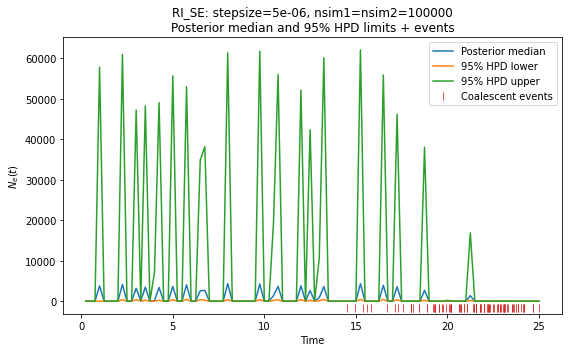


RI_SE: stepsize=5e-05, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_5e-5_nsim1_100000_nsim2_100000.npz


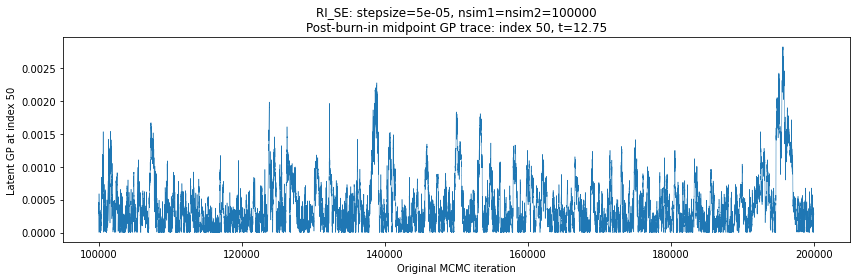

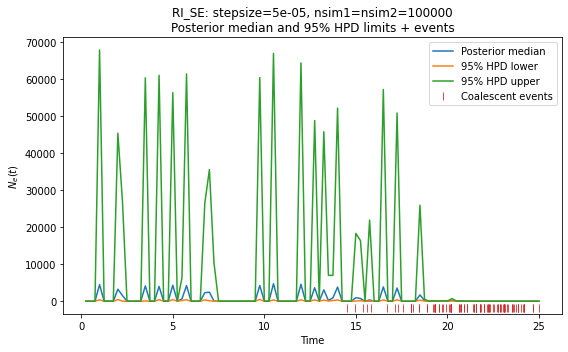


RI_SE: stepsize=0.0005, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_0.0005_nsim1_100000_nsim2_100000.npz


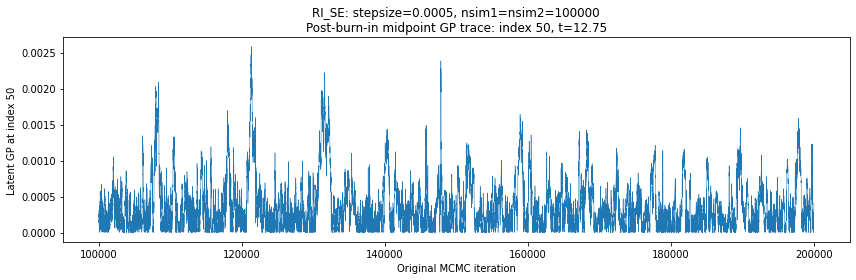

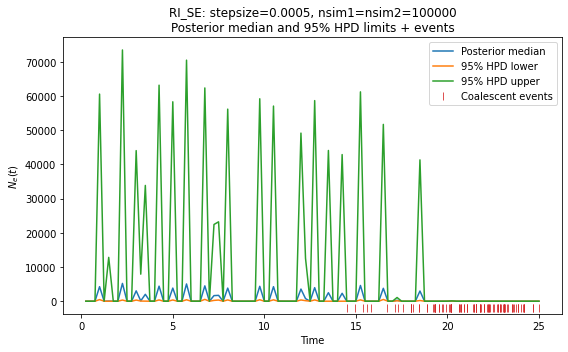


RI_SE: stepsize=0.001, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_0.001_nsim1_100000_nsim2_100000.npz


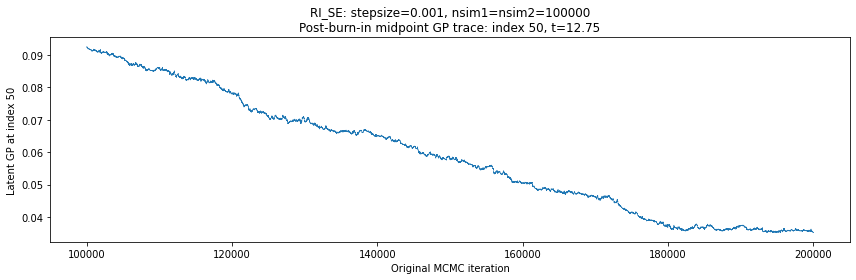

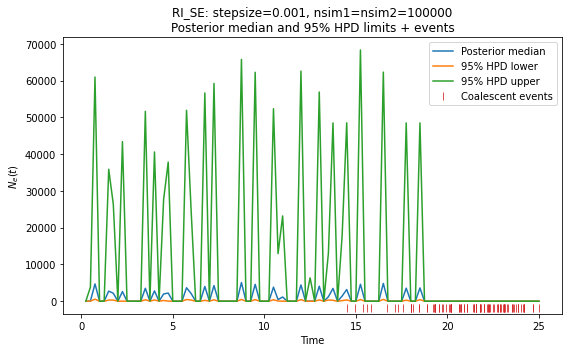


RI_SE: stepsize=0.005, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_0.005_nsim1_100000_nsim2_100000.npz


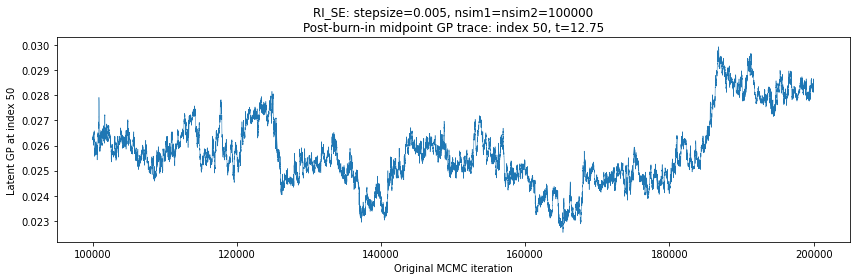

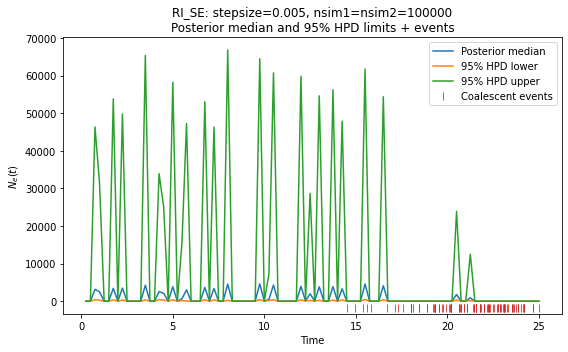


RI_SE: stepsize=0.05, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_0.05_nsim1_100000_nsim2_100000.npz


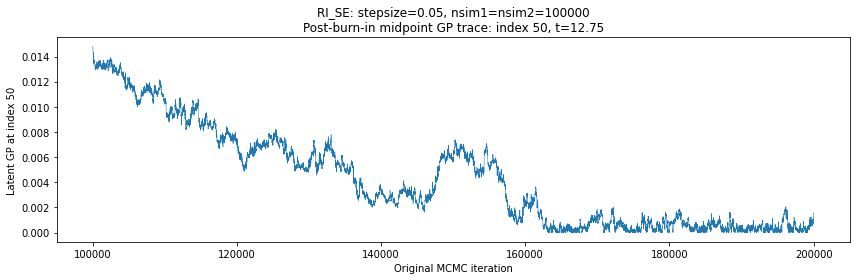

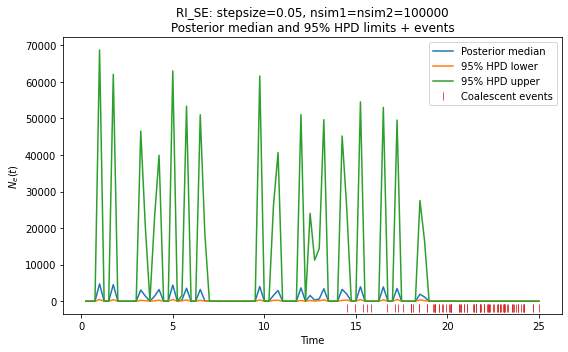


RI_SE: stepsize=0.01, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_0.01_nsim1_100000_nsim2_100000.npz


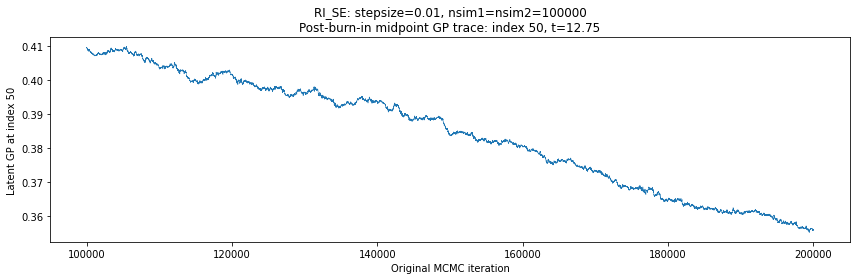

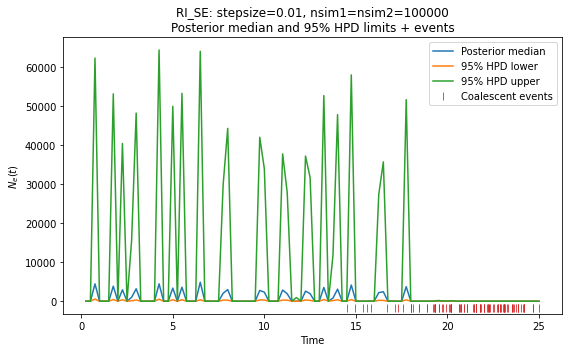


RI_SE: stepsize=0.1, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_0.1_nsim1_100000_nsim2_100000.npz


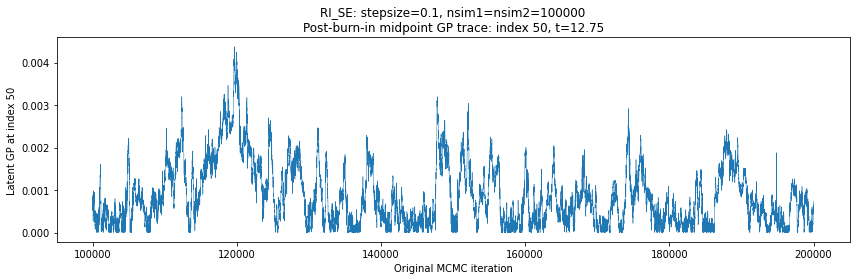

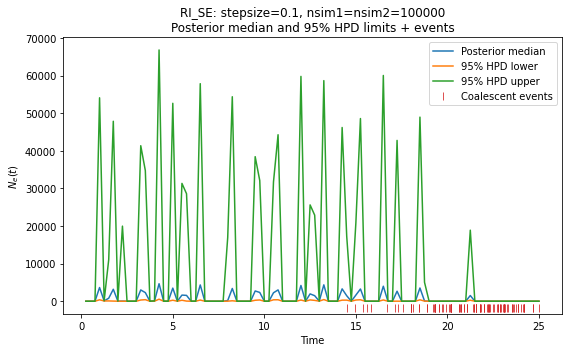


RI_SE: stepsize=0.15, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_0.15_nsim1_100000_nsim2_100000.npz


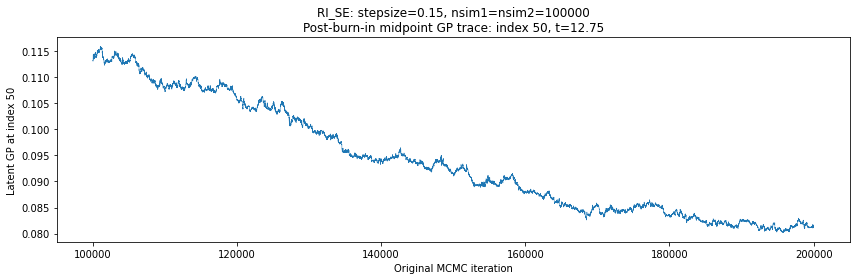

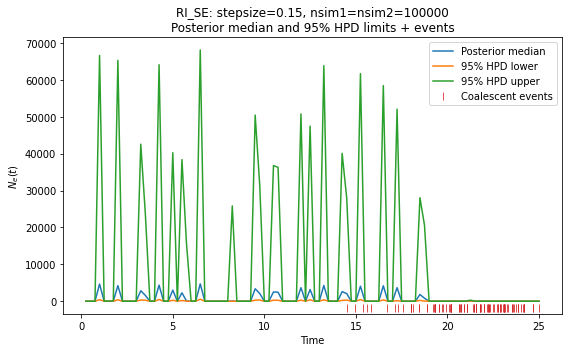


RI_SE: stepsize=0.2, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_0.2_nsim1_100000_nsim2_100000.npz


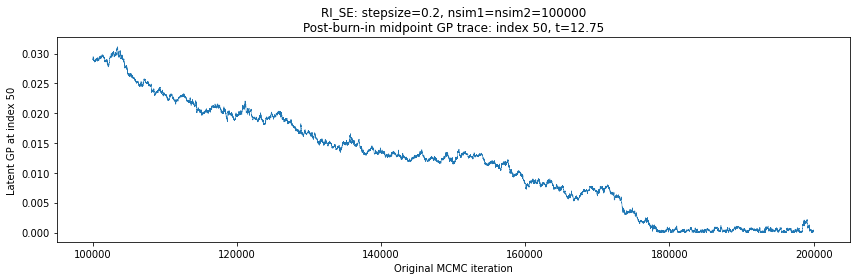

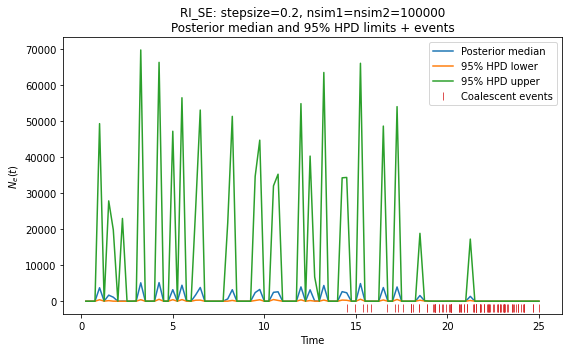


RI_SE: stepsize=0.3, nsim1=nsim2=100000
[historical output directory]/real100_SE_RI_stepsize_0.3_nsim1_100000_nsim2_100000.npz


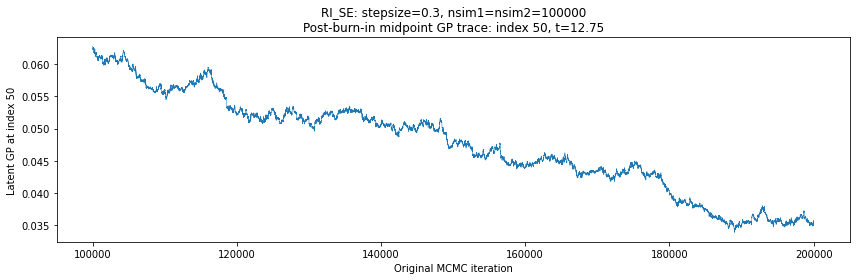

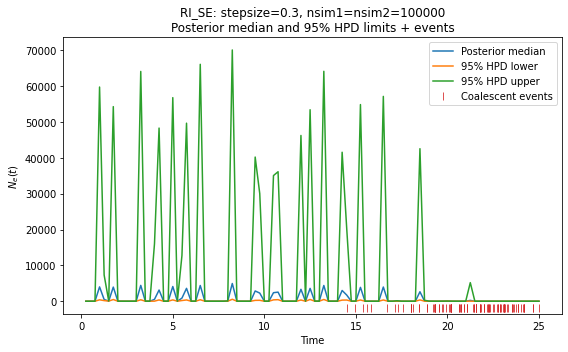


RI_SE: stepsize=5e-06, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_5e-6_nsim1_200000_nsim2_200000.npz


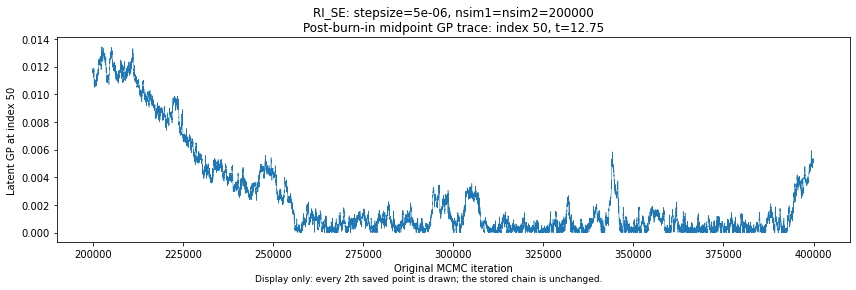

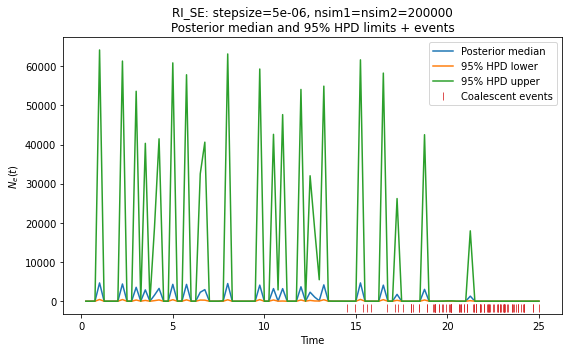


RI_SE: stepsize=5e-05, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_5e-5_nsim1_200000_nsim2_200000.npz


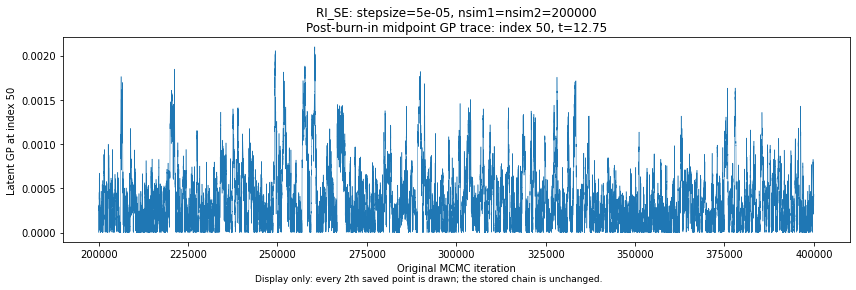

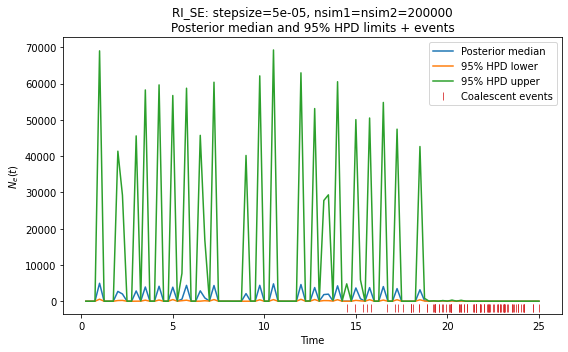


RI_SE: stepsize=0.0005, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_0.0005_nsim1_200000_nsim2_200000.npz


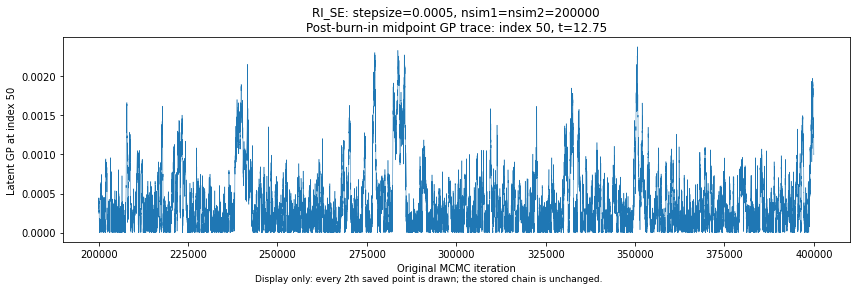

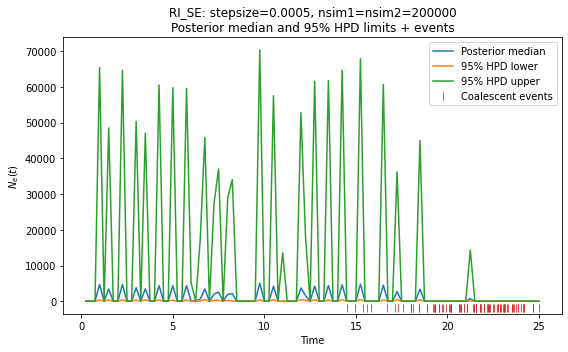


RI_SE: stepsize=0.001, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_0.001_nsim1_200000_nsim2_200000.npz


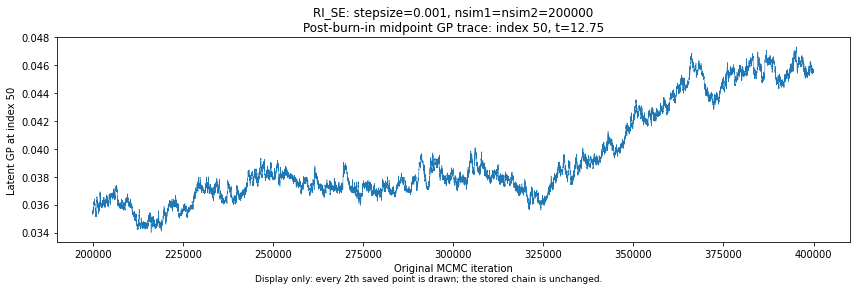

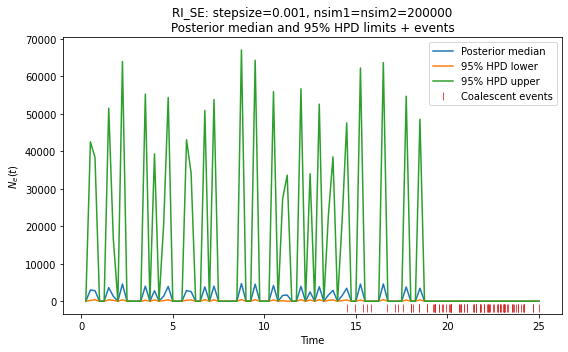


RI_SE: stepsize=0.005, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_0.005_nsim1_200000_nsim2_200000.npz


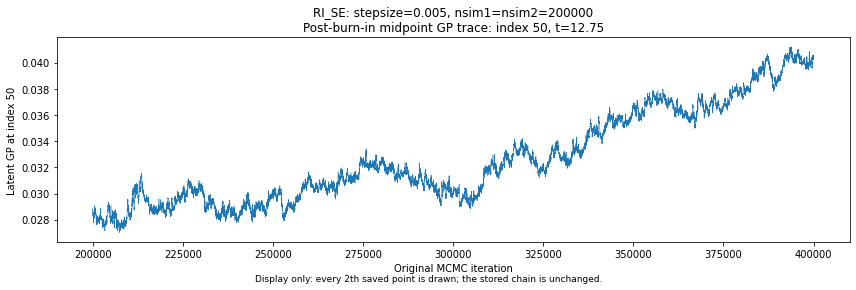

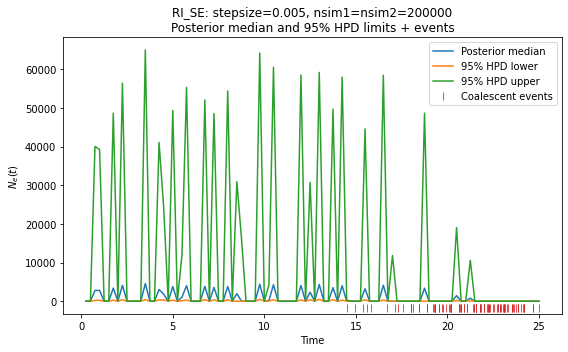


RI_SE: stepsize=0.05, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_0.05_nsim1_200000_nsim2_200000.npz


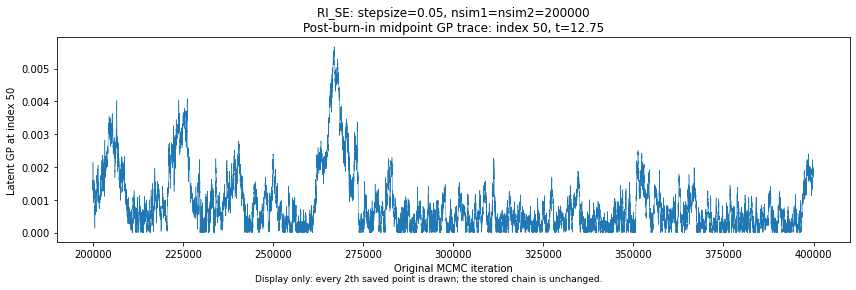

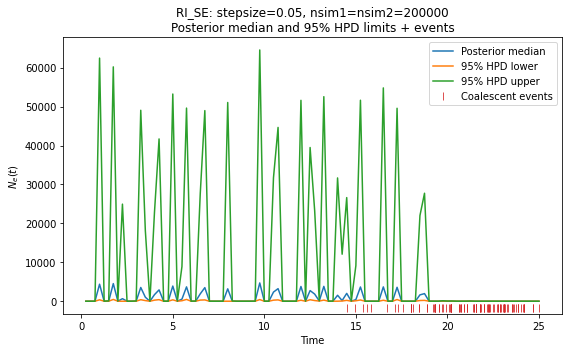


RI_SE: stepsize=0.01, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_0.01_nsim1_200000_nsim2_200000.npz


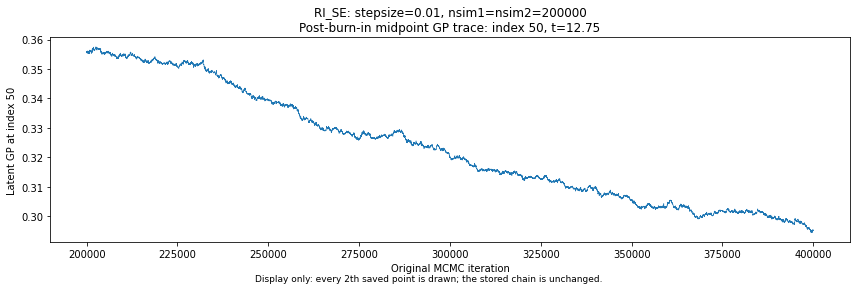

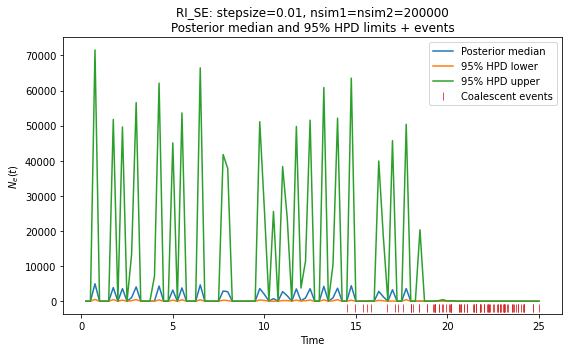


RI_SE: stepsize=0.1, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_0.1_nsim1_200000_nsim2_200000.npz


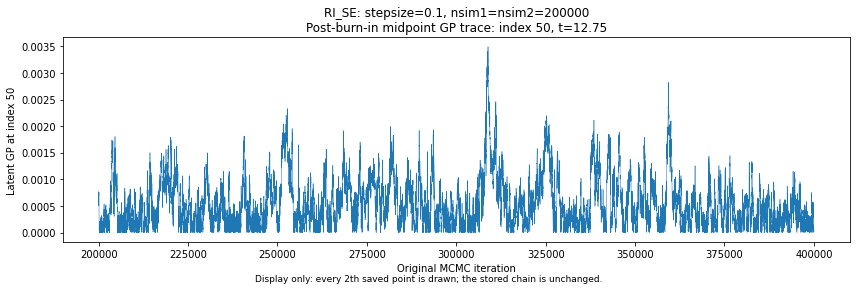

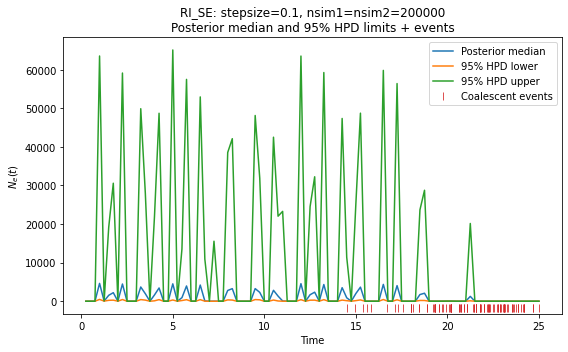


RI_SE: stepsize=0.15, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_0.15_nsim1_200000_nsim2_200000.npz


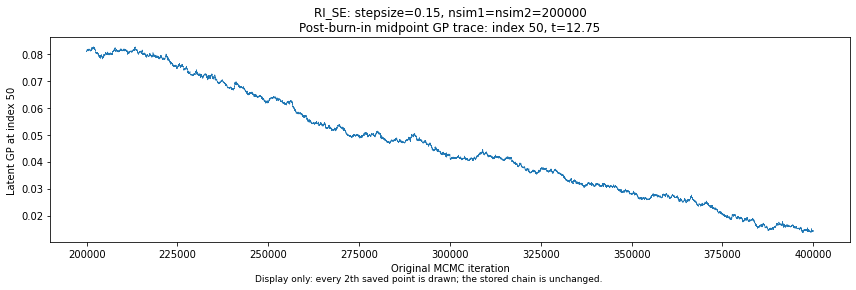

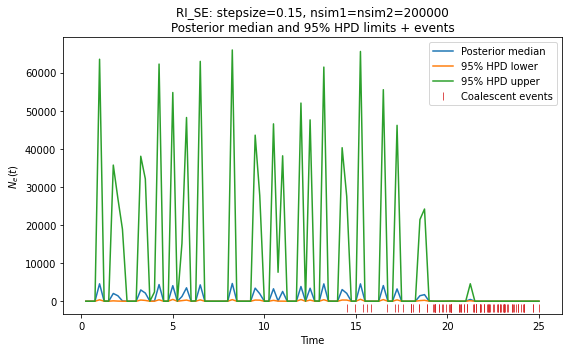


RI_SE: stepsize=0.2, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_0.2_nsim1_200000_nsim2_200000.npz


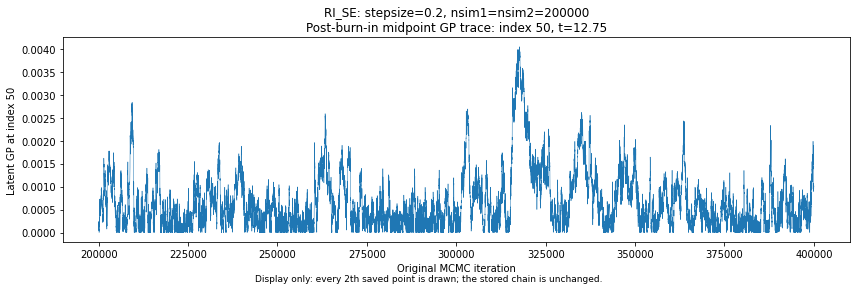

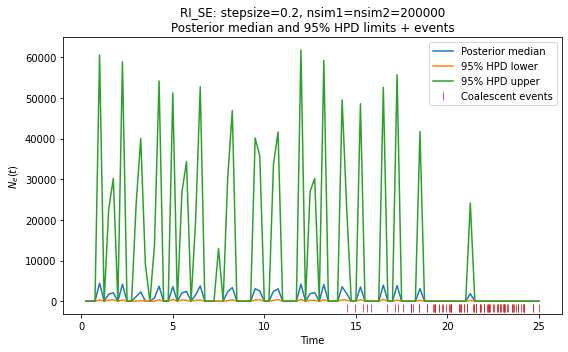


RI_SE: stepsize=0.3, nsim1=nsim2=200000
[historical output directory]/real100_SE_RI_stepsize_0.3_nsim1_200000_nsim2_200000.npz


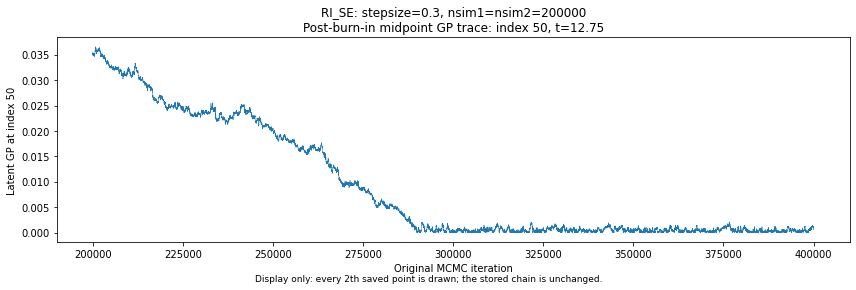

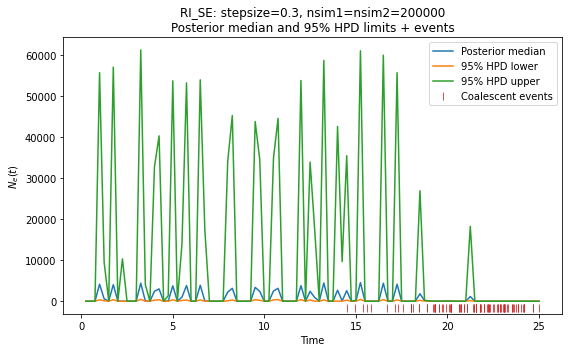


RI_SE: stepsize=5e-06, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_5e-6_nsim1_300000_nsim2_300000.npz


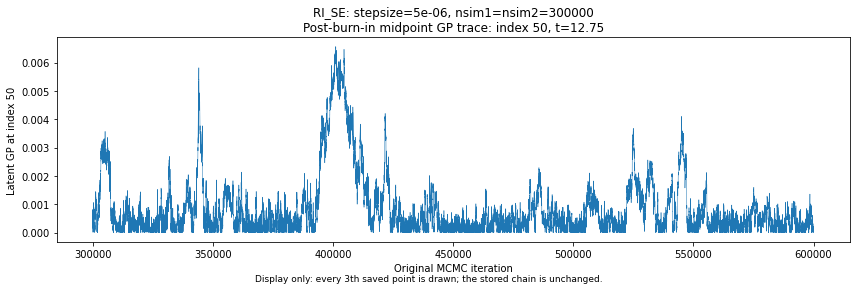

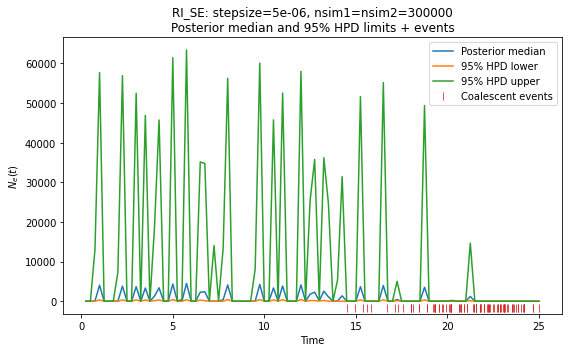


RI_SE: stepsize=5e-05, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_5e-5_nsim1_300000_nsim2_300000.npz


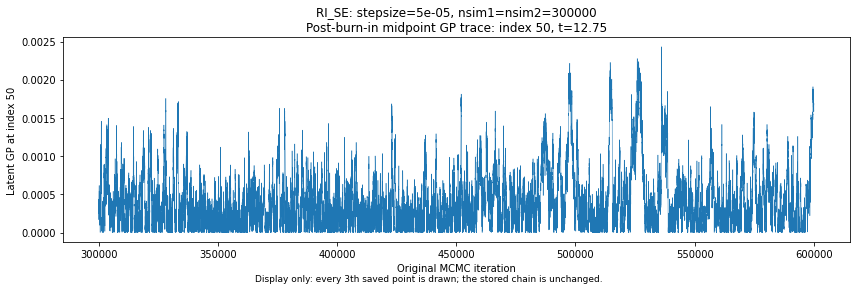

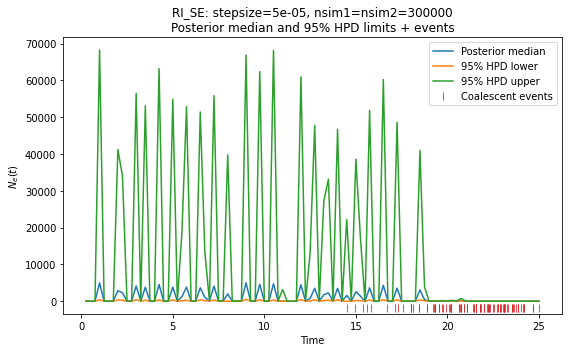


RI_SE: stepsize=0.0005, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_0.0005_nsim1_300000_nsim2_300000.npz


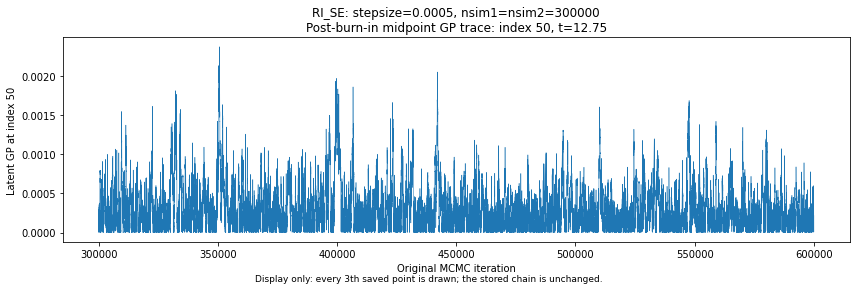

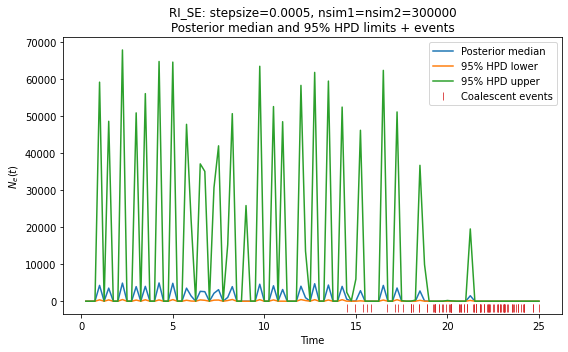


RI_SE: stepsize=0.001, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_0.001_nsim1_300000_nsim2_300000.npz


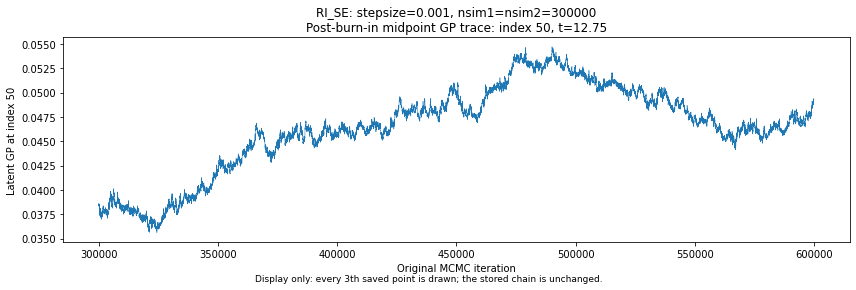

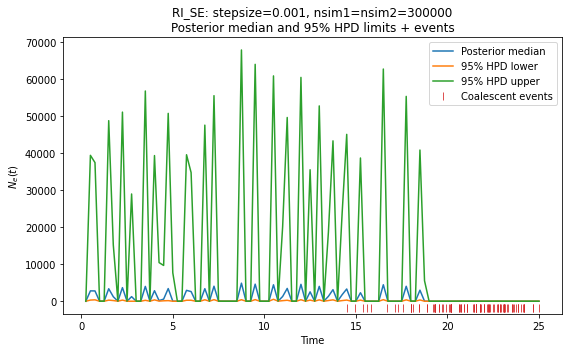


RI_SE: stepsize=0.005, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_0.005_nsim1_300000_nsim2_300000.npz


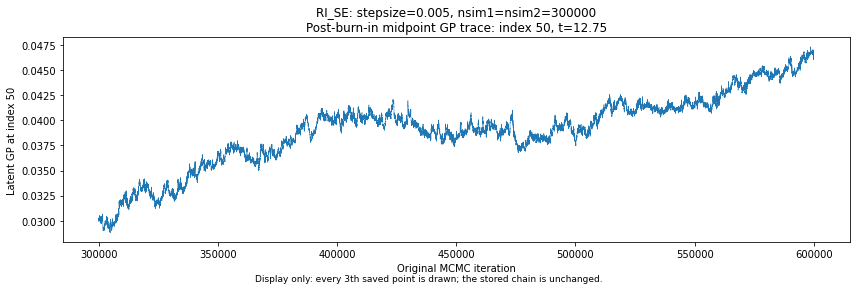

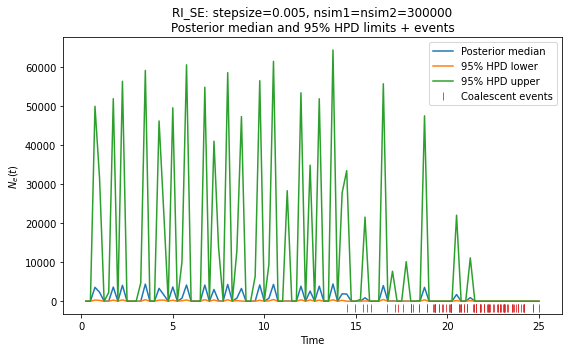


RI_SE: stepsize=0.05, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_0.05_nsim1_300000_nsim2_300000.npz


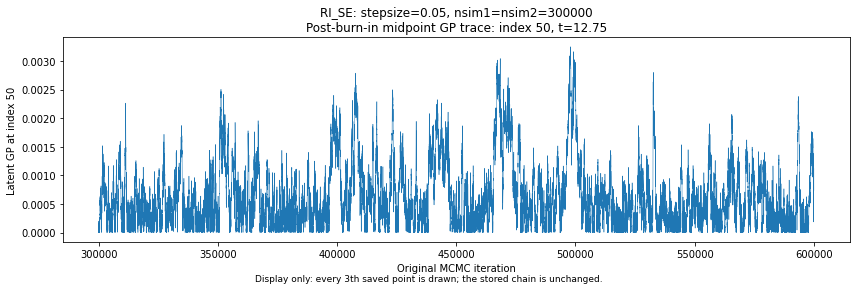

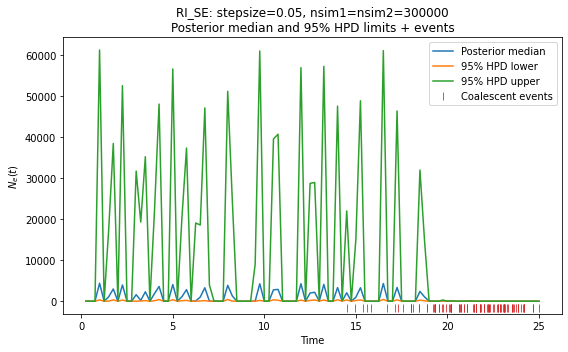


RI_SE: stepsize=0.01, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_0.01_nsim1_300000_nsim2_300000.npz


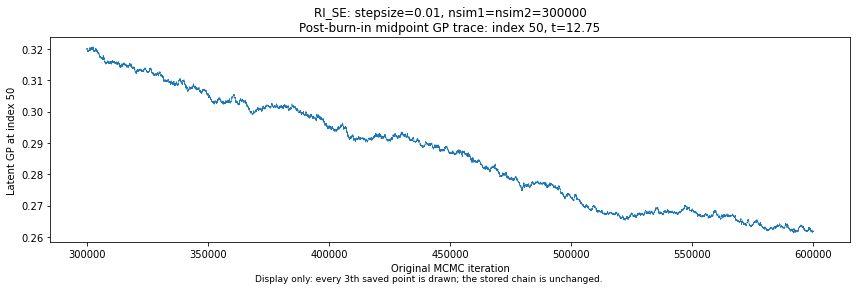

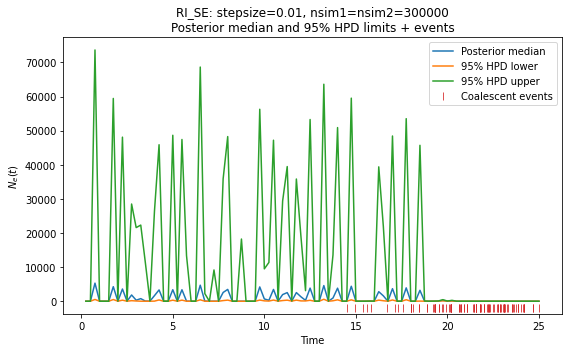


RI_SE: stepsize=0.1, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_0.1_nsim1_300000_nsim2_300000.npz


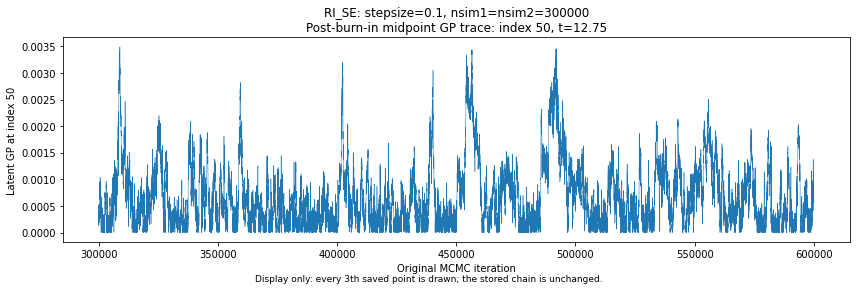

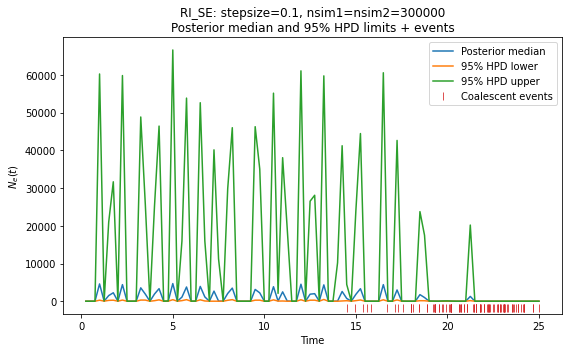


RI_SE: stepsize=0.15, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_0.15_nsim1_300000_nsim2_300000.npz


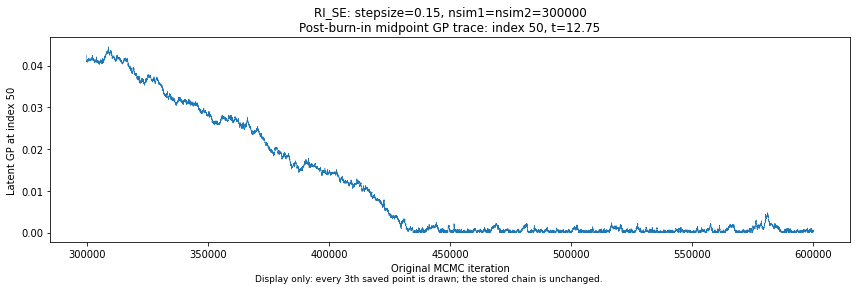

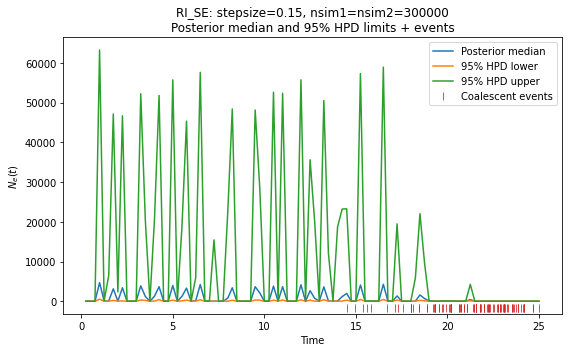


RI_SE: stepsize=0.2, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_0.2_nsim1_300000_nsim2_300000.npz


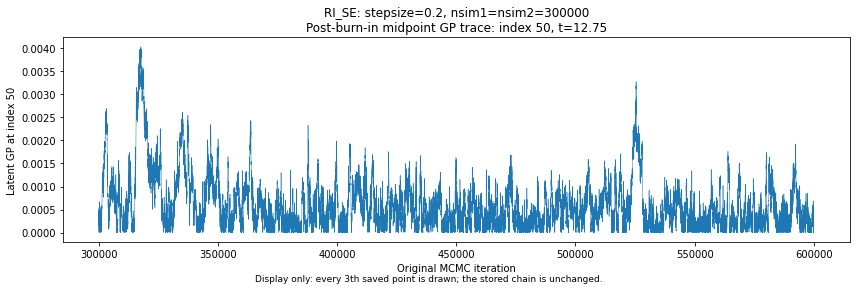

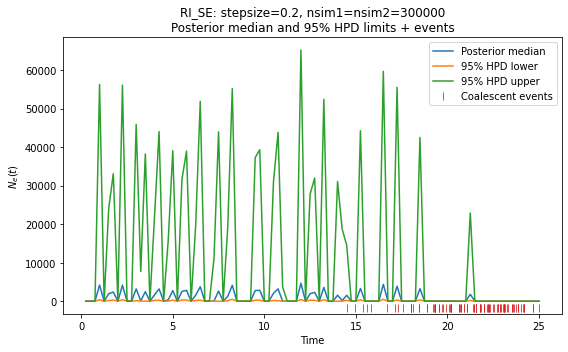


RI_SE: stepsize=0.3, nsim1=nsim2=300000
[historical output directory]/real100_SE_RI_stepsize_0.3_nsim1_300000_nsim2_300000.npz


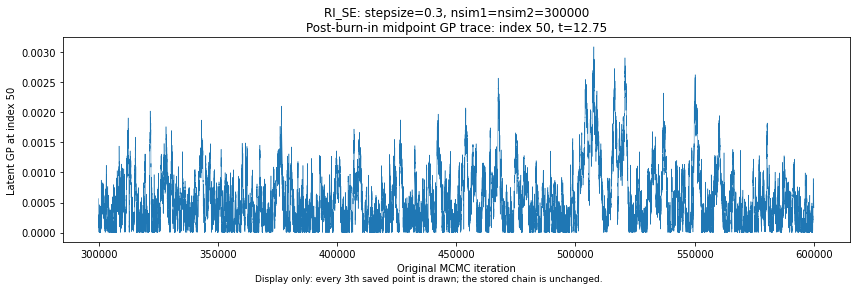

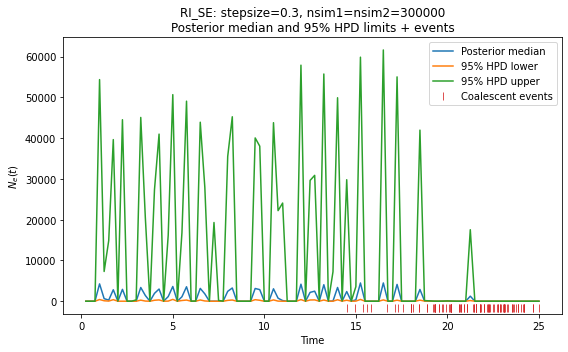


RI_SE: stepsize=5e-06, nsim1=nsim2=500000
[historical output directory]/real100_SE_RI_stepsize_5e-6_nsim1_500000_nsim2_500000.npz
MISSING -> skipped

RI_SE: stepsize=5e-05, nsim1=nsim2=500000
[historical output directory]/real100_SE_RI_stepsize_5e-5_nsim1_500000_nsim2_500000.npz
MISSING -> skipped

RI_SE: stepsize=0.0005, nsim1=nsim2=500000
[historical output directory]/real100_SE_RI_stepsize_0.0005_nsim1_500000_nsim2_500000.npz
MISSING -> skipped

RI_SE: stepsize=0.001, nsim1=nsim2=500000
[historical output directory]/real100_SE_RI_stepsize_0.001_nsim1_500000_nsim2_500000.npz
MISSING -> skipped

RI_SE: stepsize=0.005, nsim1=nsim2=500000
[historical output directory]/real100_SE_RI_stepsize_0.005_nsim1_500000_nsim2_500000.npz
MISSING -> skipped

RI_SE: stepsize=0.05, nsim1=nsim2=500000
[historical output directory]/real100_SE_RI_stepsize_0.05_nsim1_500000_nsim2_500000.npz
MISSING -> skipped

RI_SE: stepsize=0.01, nsim1=nsim2=500000
[historical output directory]/real100_SE_RI_stepsize_0

In [8]:
missing_RI_SE = []

for nsim in SE_NSIM_VALUES:
    for proposal in SE_PROPOSAL_VALUES:
        ok = plot_one_setting(
            "RI_SE",
            proposal=proposal,
            nsim=nsim,
        )
        if not ok:
            missing_RI_SE.append((proposal, nsim))

print("\nMissing RI-SE settings:")
print(missing_RI_SE)


## DIS-SE: all 44 settings


DIS_SE: stepsize=5e-06, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_5e-6_nsim1_100000_nsim2_100000.npz


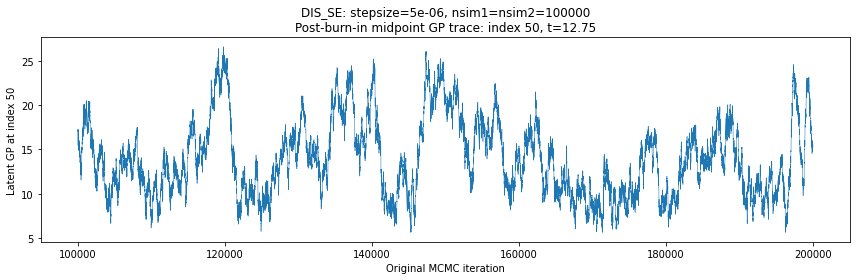

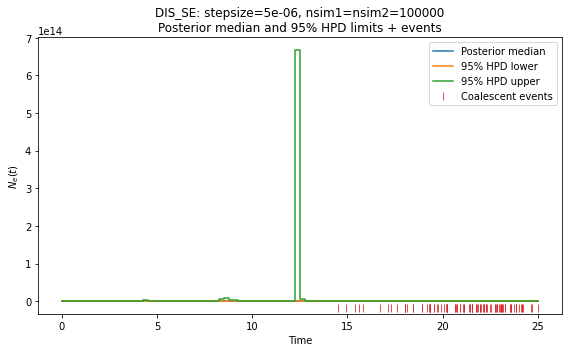


DIS_SE: stepsize=5e-05, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_5e-5_nsim1_100000_nsim2_100000.npz


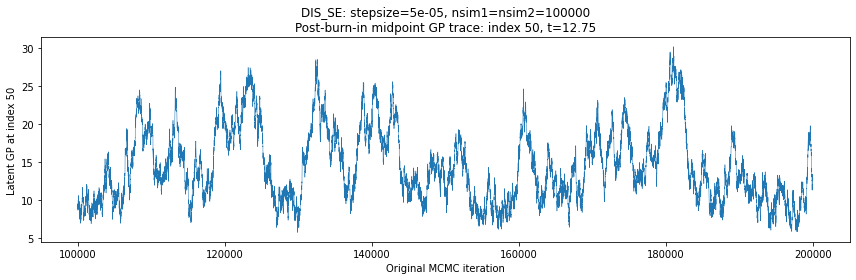

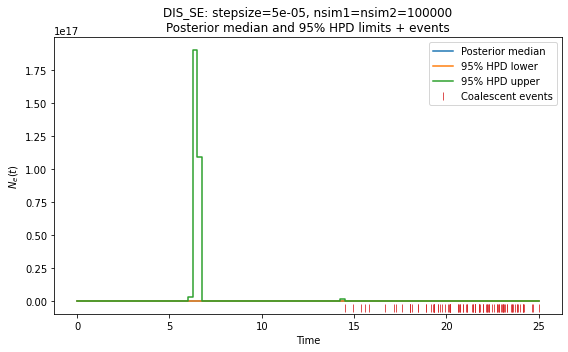


DIS_SE: stepsize=0.0005, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_0.0005_nsim1_100000_nsim2_100000.npz


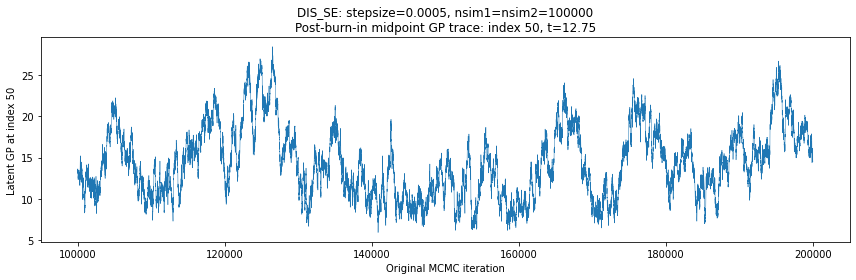

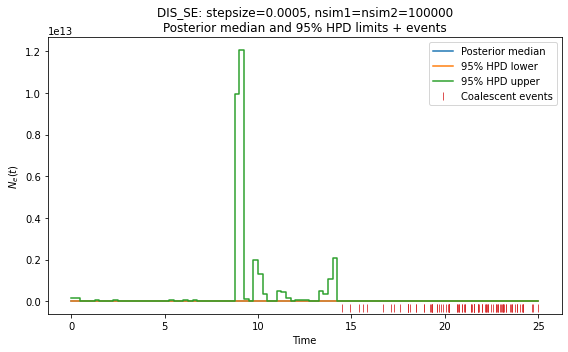


DIS_SE: stepsize=0.001, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_0.001_nsim1_100000_nsim2_100000.npz


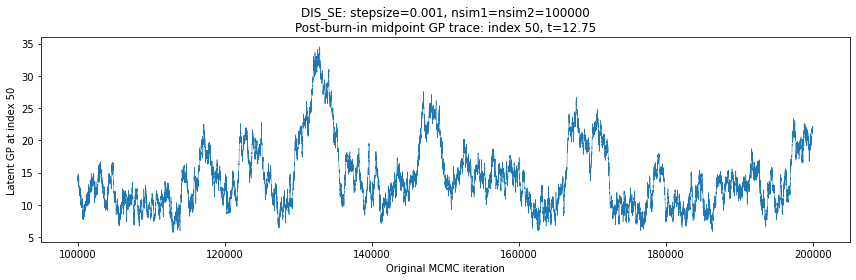

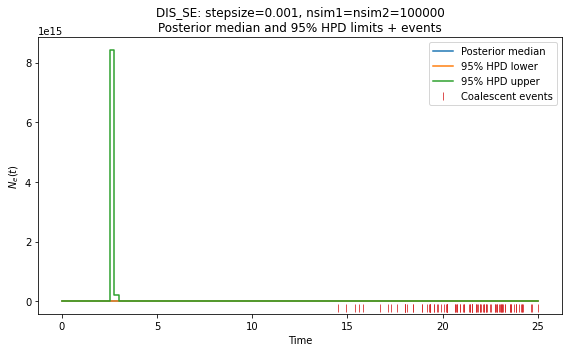


DIS_SE: stepsize=0.005, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_0.005_nsim1_100000_nsim2_100000.npz


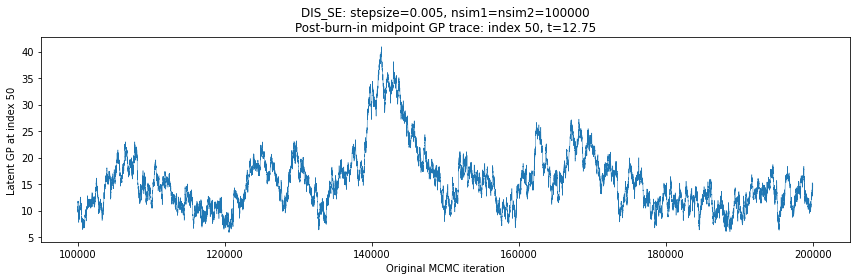

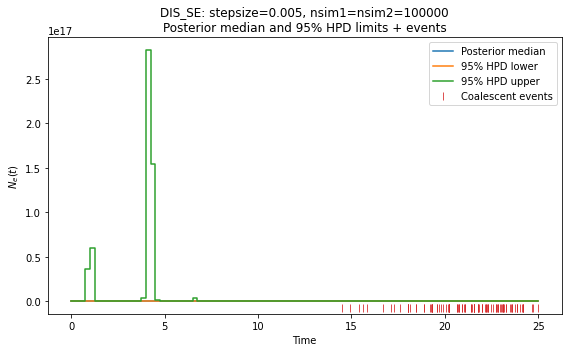


DIS_SE: stepsize=0.05, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_0.05_nsim1_100000_nsim2_100000.npz


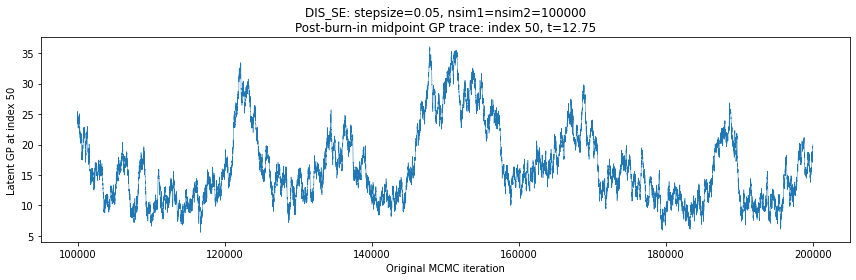

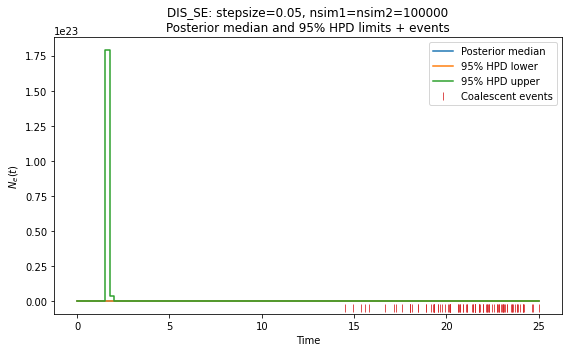


DIS_SE: stepsize=0.01, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_0.01_nsim1_100000_nsim2_100000.npz


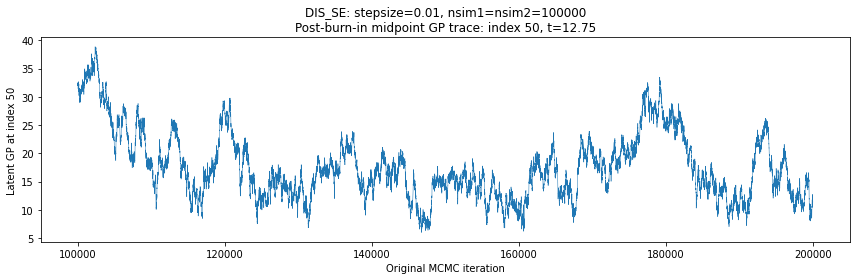

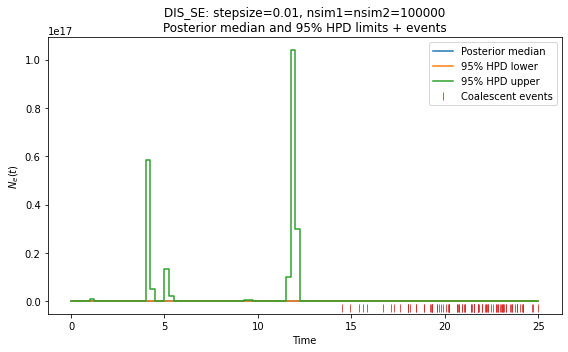


DIS_SE: stepsize=0.1, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_0.1_nsim1_100000_nsim2_100000.npz


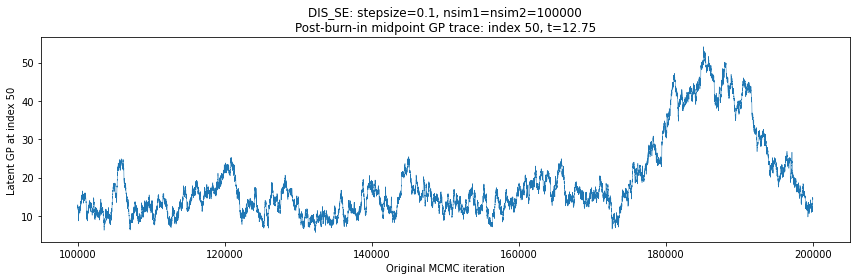

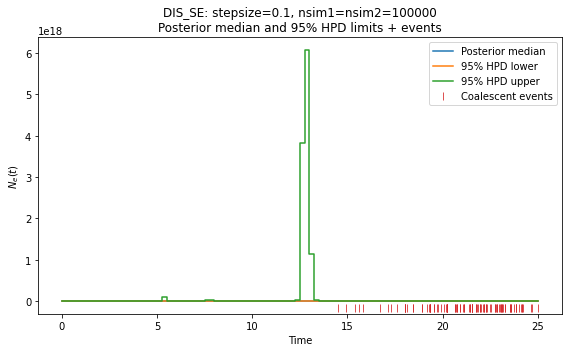


DIS_SE: stepsize=0.15, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_0.15_nsim1_100000_nsim2_100000.npz


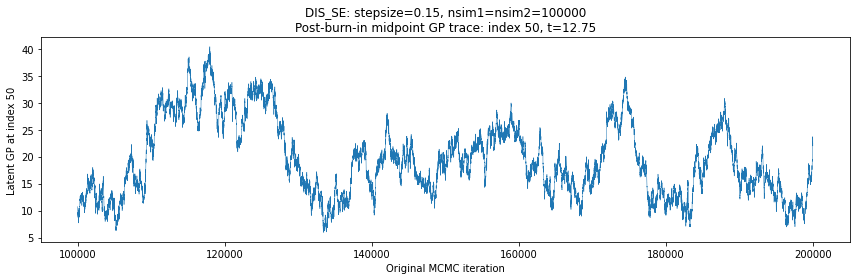

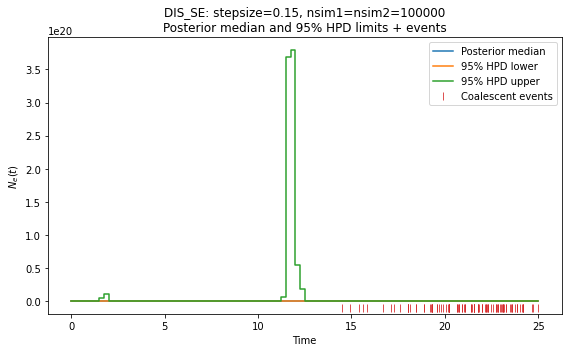


DIS_SE: stepsize=0.2, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_0.2_nsim1_100000_nsim2_100000.npz


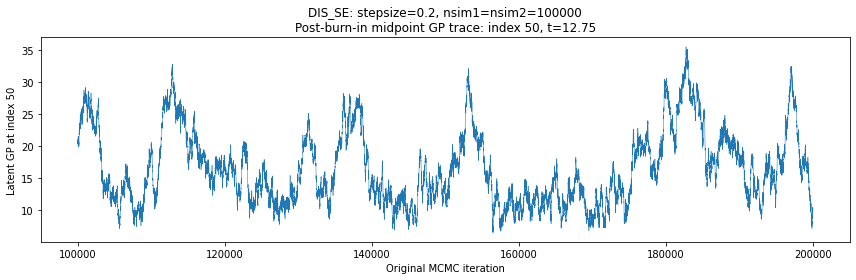

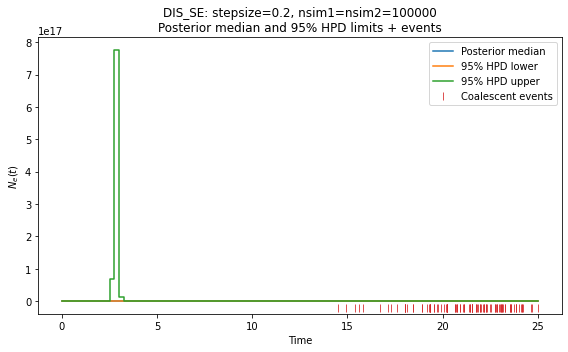


DIS_SE: stepsize=0.3, nsim1=nsim2=100000
[historical output directory]/real100_SE_DIS_stepsize_0.3_nsim1_100000_nsim2_100000.npz


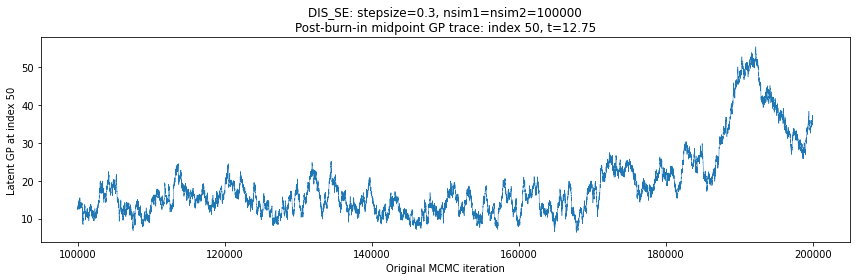

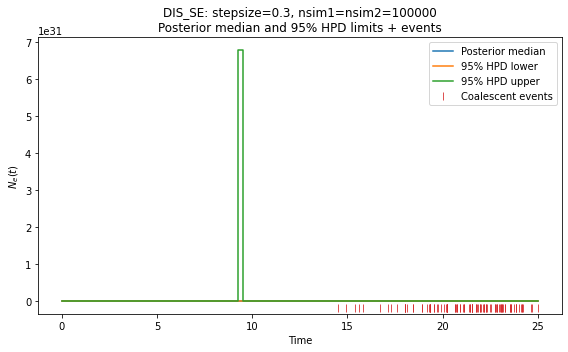


DIS_SE: stepsize=5e-06, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_5e-6_nsim1_200000_nsim2_200000.npz


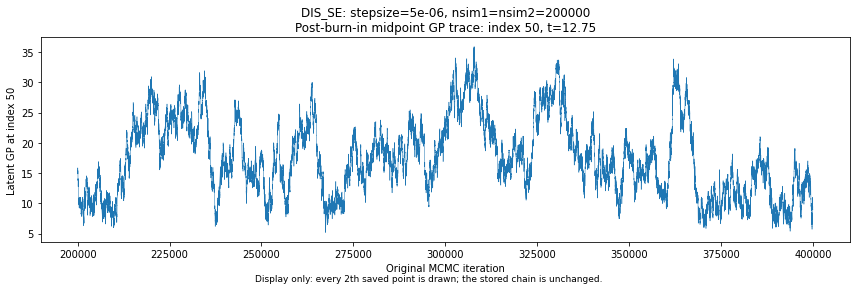

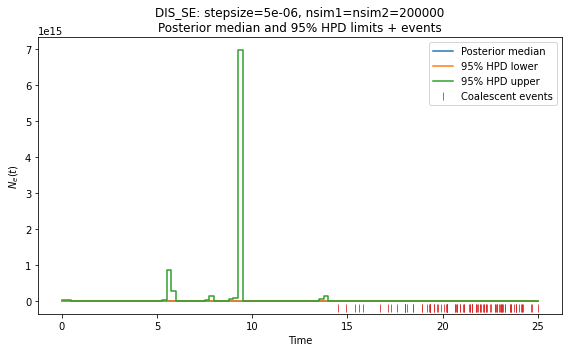


DIS_SE: stepsize=5e-05, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_5e-5_nsim1_200000_nsim2_200000.npz


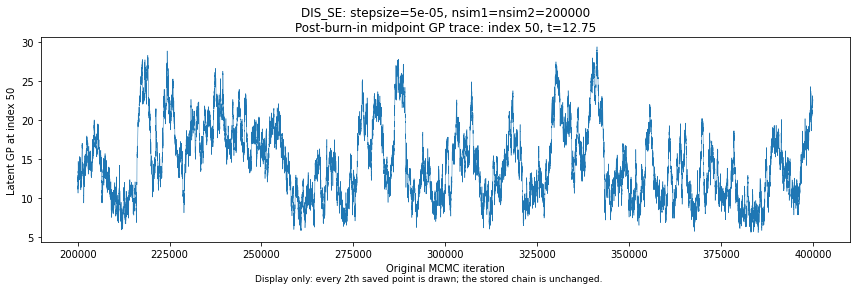

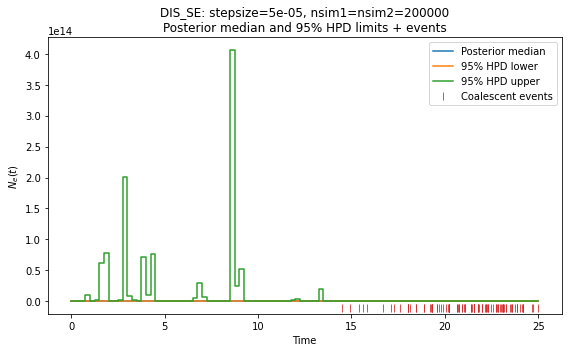


DIS_SE: stepsize=0.0005, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_0.0005_nsim1_200000_nsim2_200000.npz


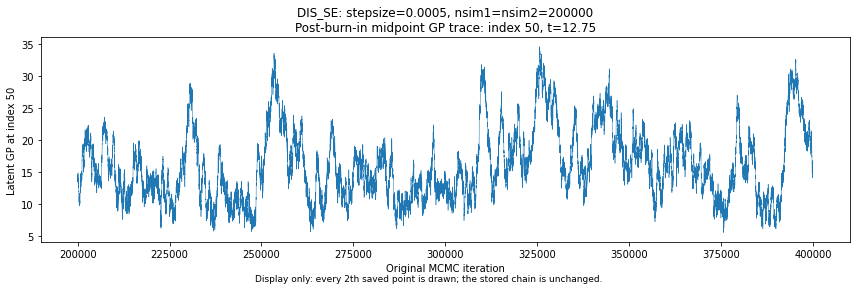

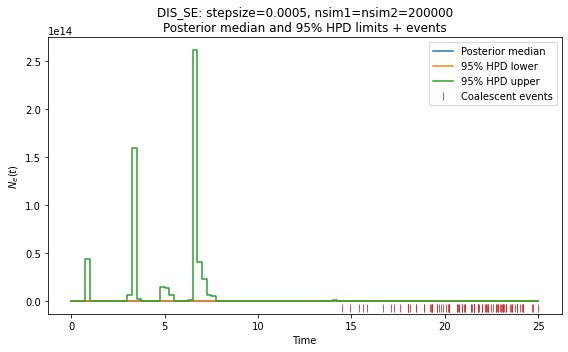


DIS_SE: stepsize=0.001, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_0.001_nsim1_200000_nsim2_200000.npz


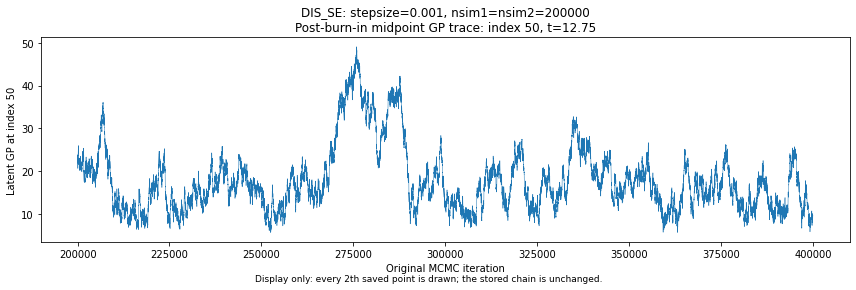

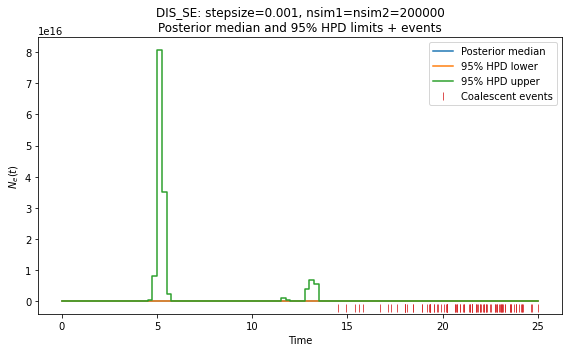


DIS_SE: stepsize=0.005, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_0.005_nsim1_200000_nsim2_200000.npz


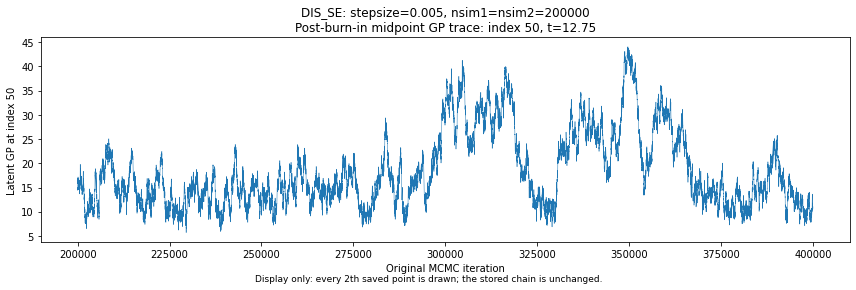

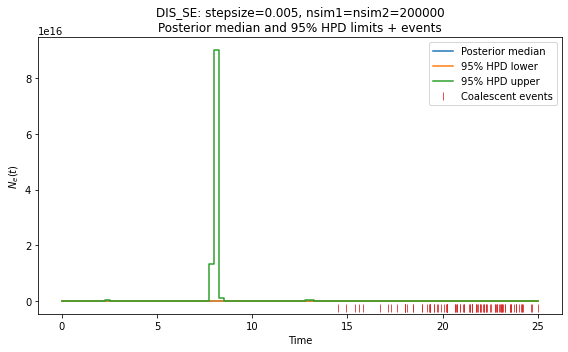


DIS_SE: stepsize=0.05, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_0.05_nsim1_200000_nsim2_200000.npz


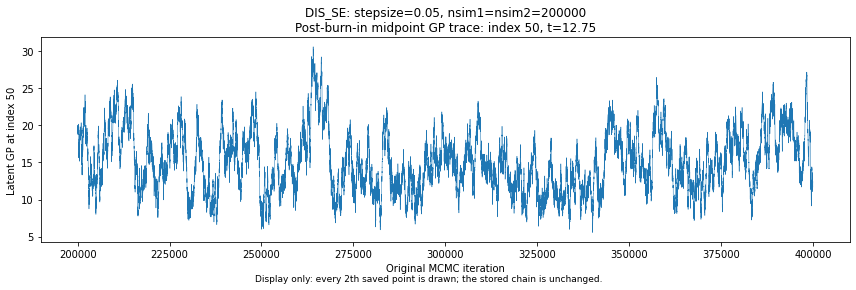

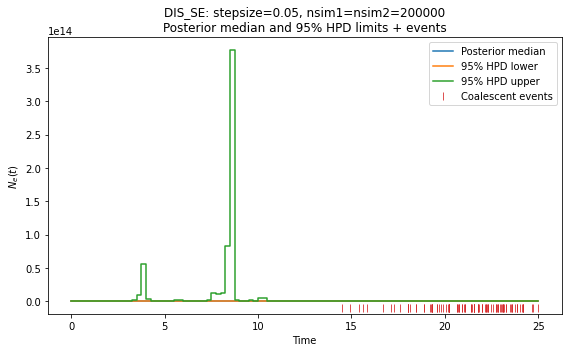


DIS_SE: stepsize=0.01, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_0.01_nsim1_200000_nsim2_200000.npz


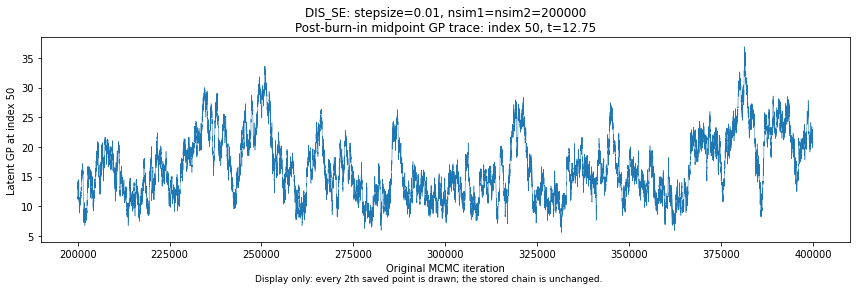

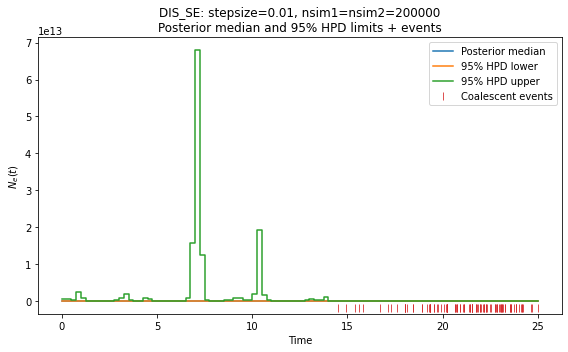


DIS_SE: stepsize=0.1, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_0.1_nsim1_200000_nsim2_200000.npz


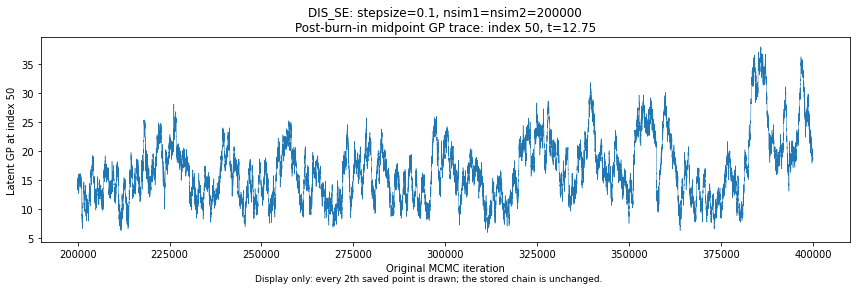

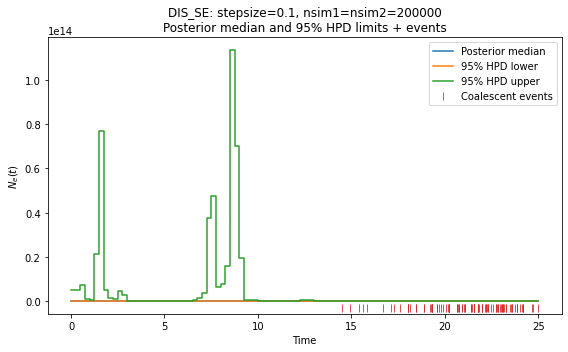


DIS_SE: stepsize=0.15, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_0.15_nsim1_200000_nsim2_200000.npz


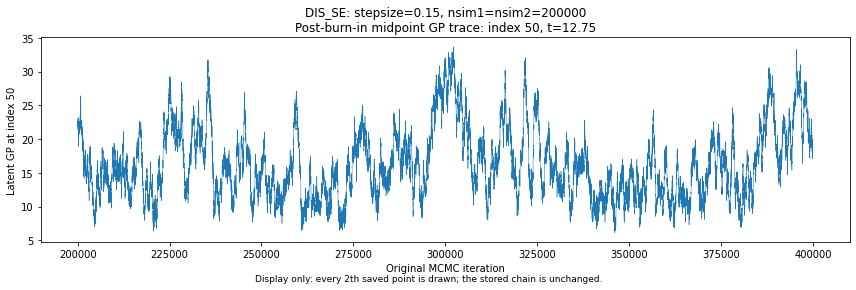

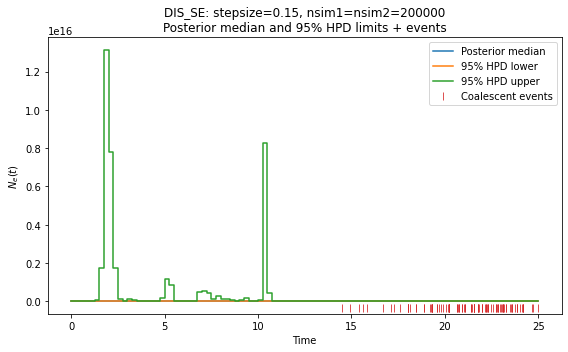


DIS_SE: stepsize=0.2, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_0.2_nsim1_200000_nsim2_200000.npz


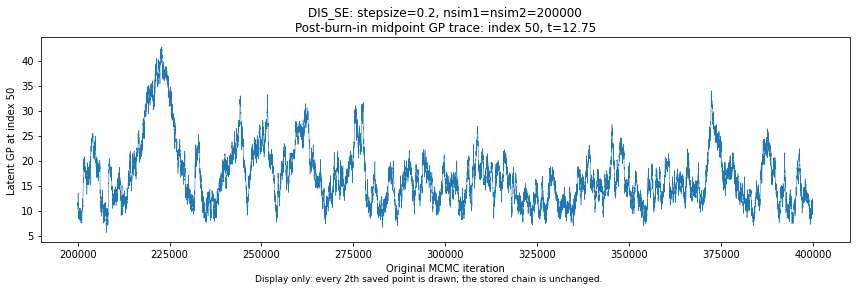

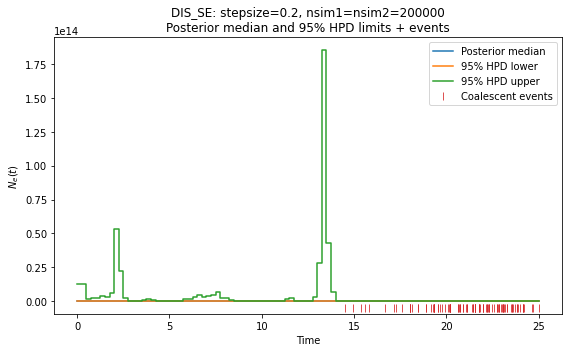


DIS_SE: stepsize=0.3, nsim1=nsim2=200000
[historical output directory]/real100_SE_DIS_stepsize_0.3_nsim1_200000_nsim2_200000.npz


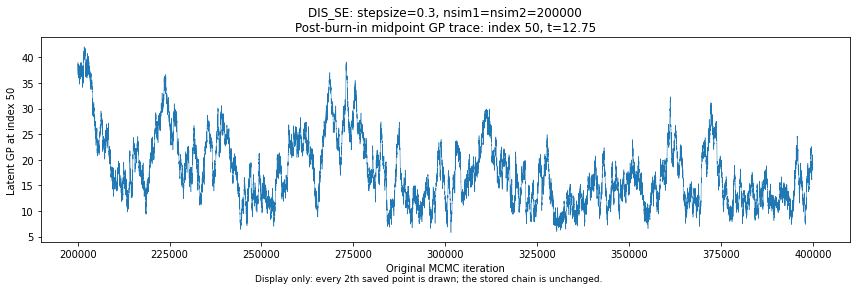

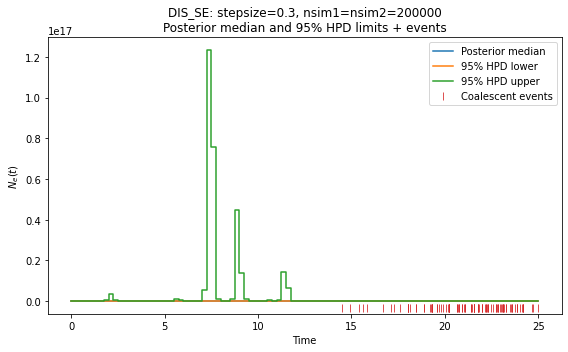


DIS_SE: stepsize=5e-06, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_5e-6_nsim1_300000_nsim2_300000.npz


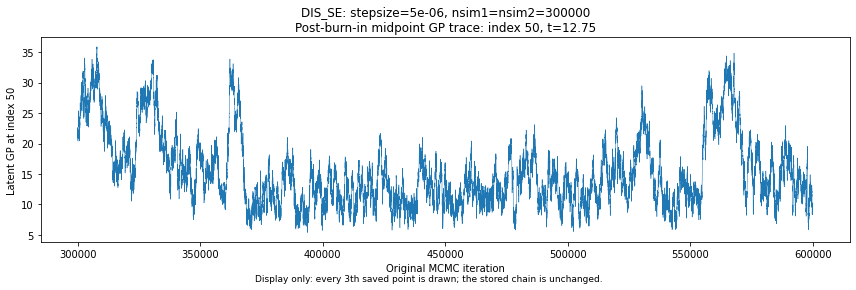

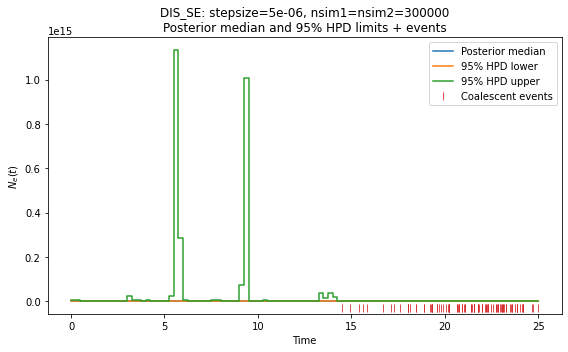


DIS_SE: stepsize=5e-05, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_5e-5_nsim1_300000_nsim2_300000.npz


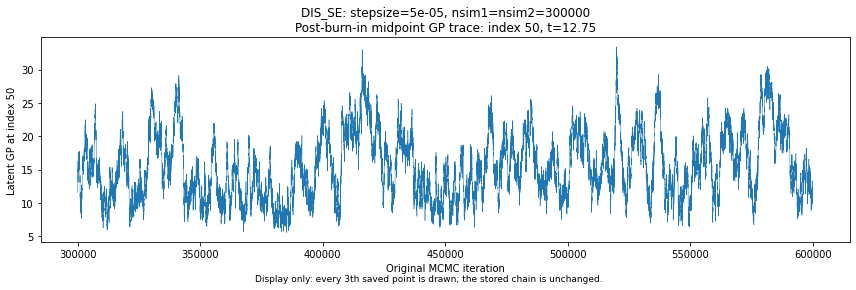

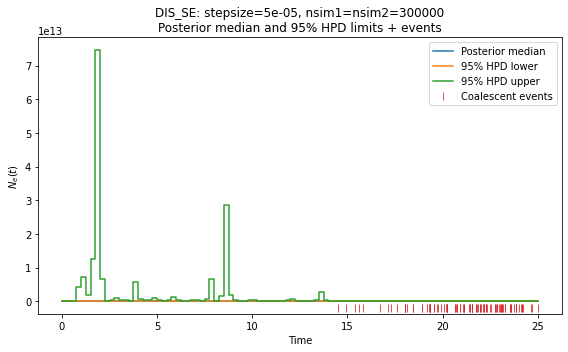


DIS_SE: stepsize=0.0005, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_0.0005_nsim1_300000_nsim2_300000.npz


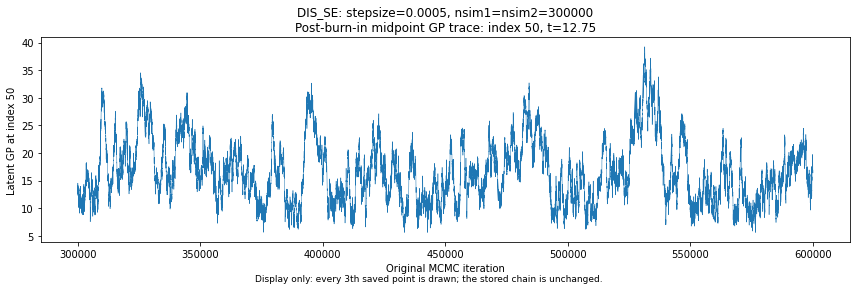

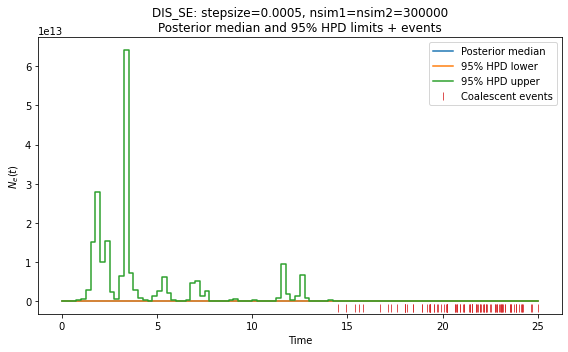


DIS_SE: stepsize=0.001, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_0.001_nsim1_300000_nsim2_300000.npz


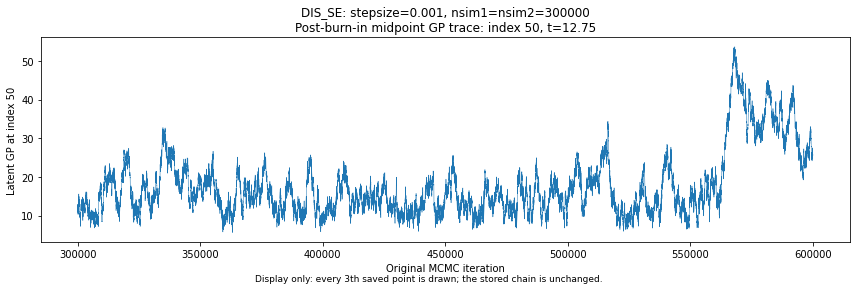

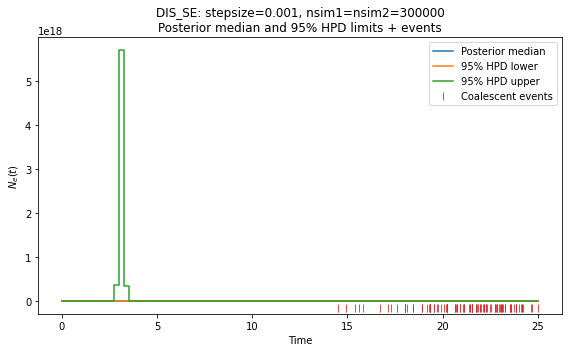


DIS_SE: stepsize=0.005, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_0.005_nsim1_300000_nsim2_300000.npz


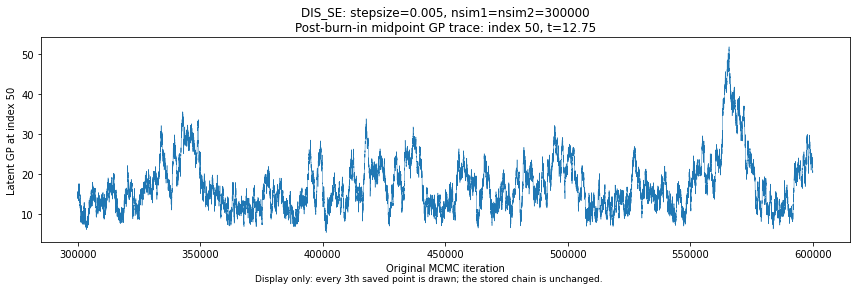

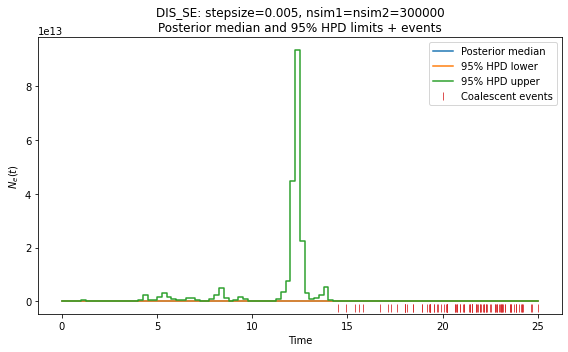


DIS_SE: stepsize=0.05, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_0.05_nsim1_300000_nsim2_300000.npz


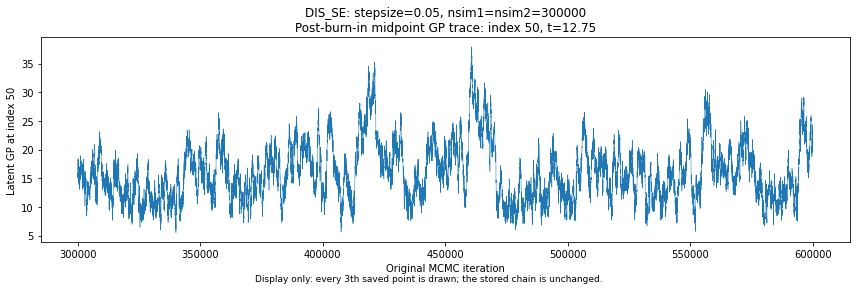

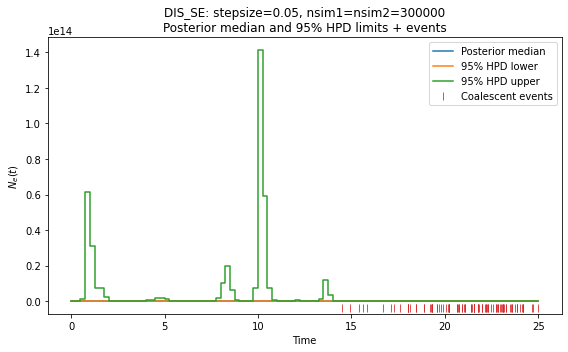


DIS_SE: stepsize=0.01, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_0.01_nsim1_300000_nsim2_300000.npz


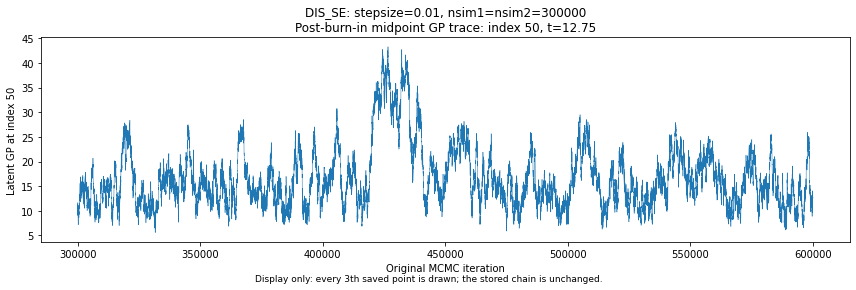

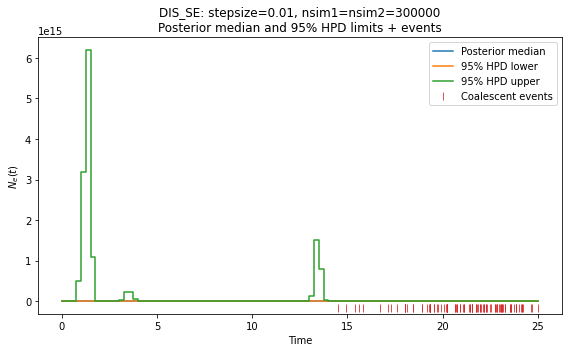


DIS_SE: stepsize=0.1, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_0.1_nsim1_300000_nsim2_300000.npz


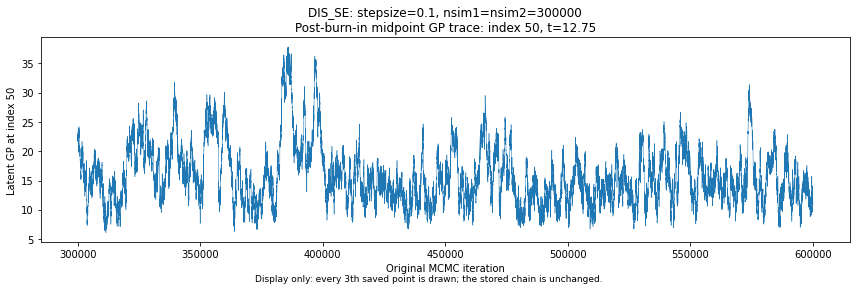

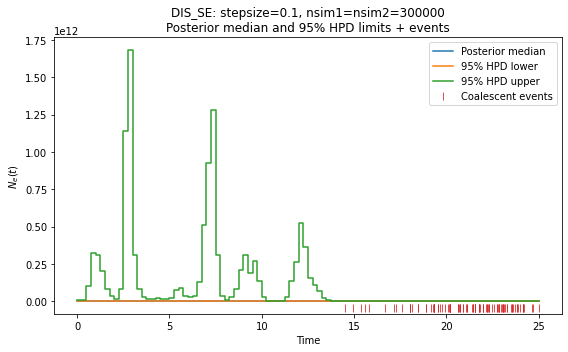


DIS_SE: stepsize=0.15, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_0.15_nsim1_300000_nsim2_300000.npz


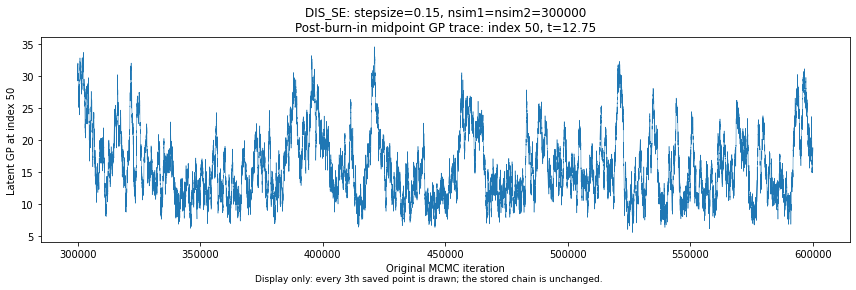

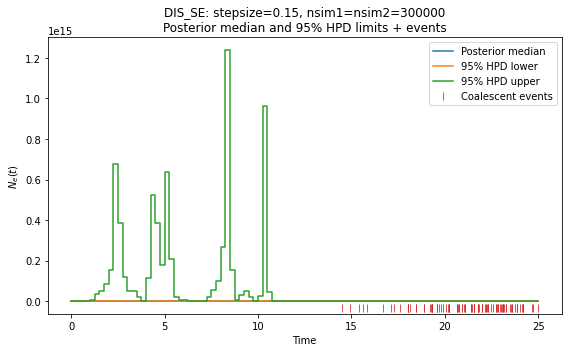


DIS_SE: stepsize=0.2, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_0.2_nsim1_300000_nsim2_300000.npz


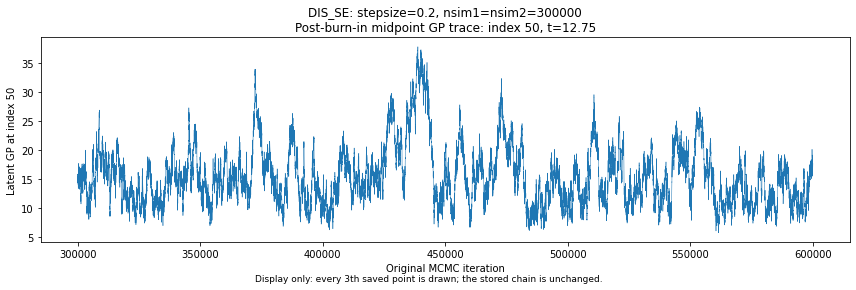

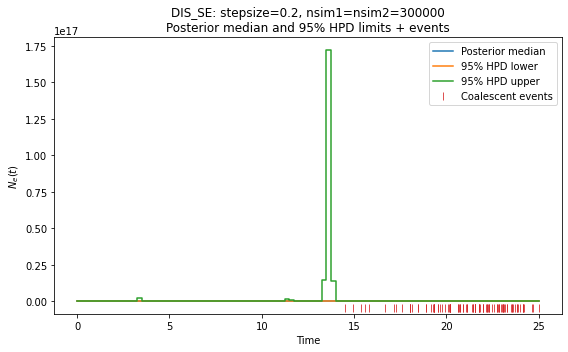


DIS_SE: stepsize=0.3, nsim1=nsim2=300000
[historical output directory]/real100_SE_DIS_stepsize_0.3_nsim1_300000_nsim2_300000.npz


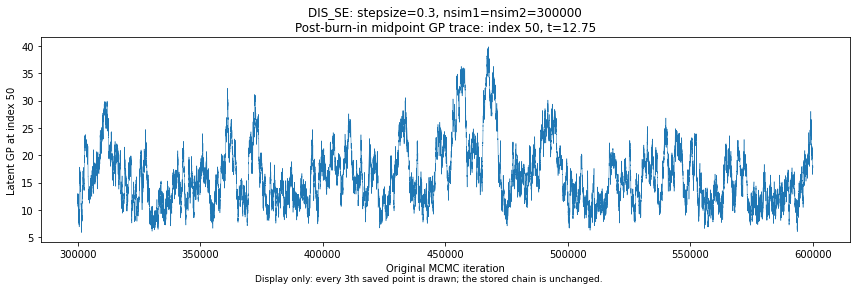

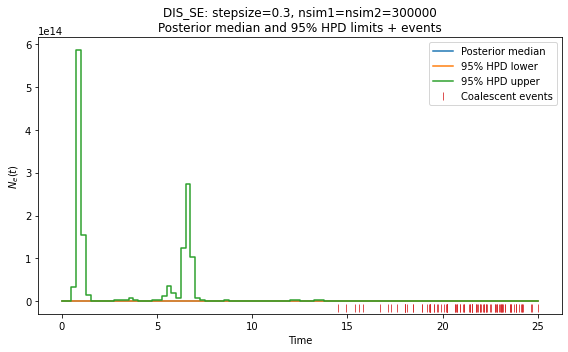


DIS_SE: stepsize=5e-06, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_5e-6_nsim1_500000_nsim2_500000.npz


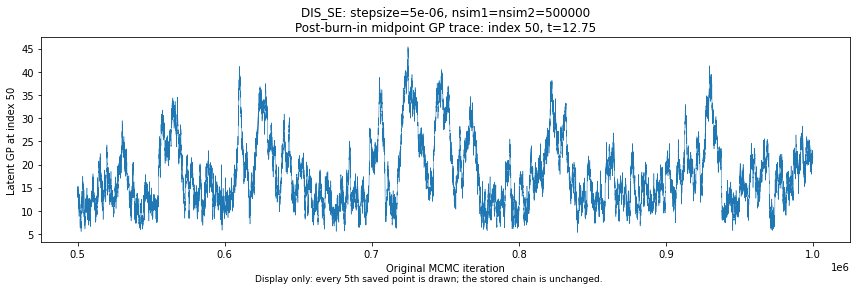

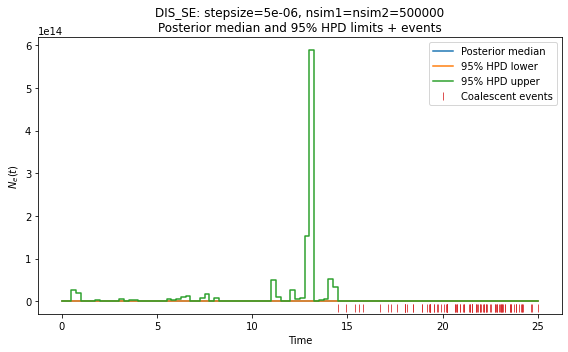


DIS_SE: stepsize=5e-05, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_5e-5_nsim1_500000_nsim2_500000.npz


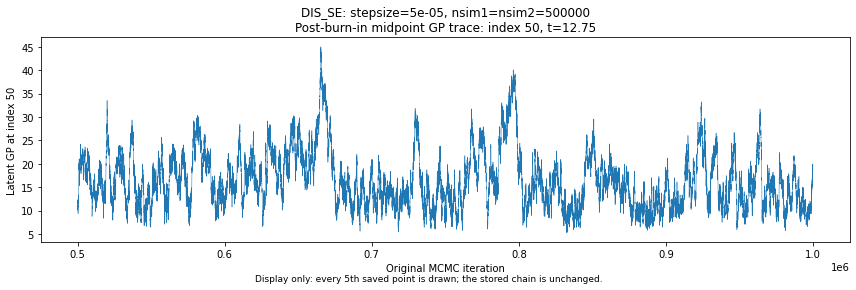

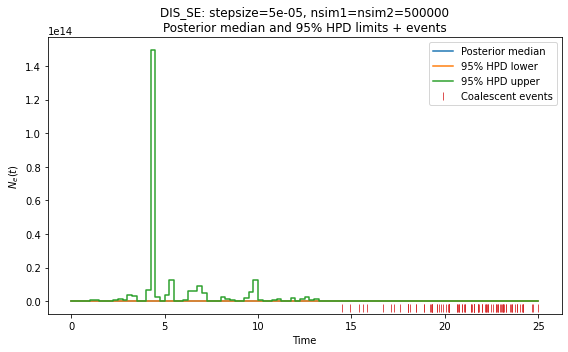


DIS_SE: stepsize=0.0005, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_0.0005_nsim1_500000_nsim2_500000.npz


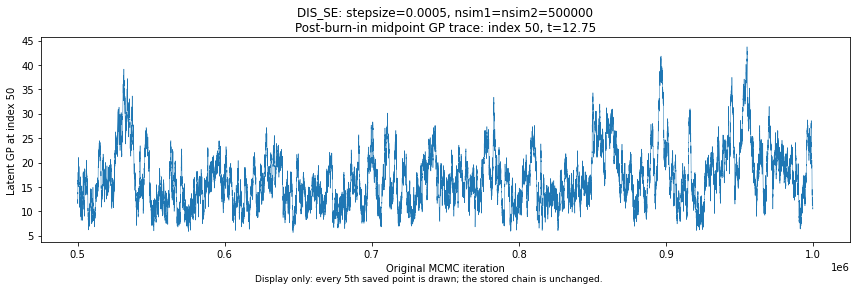

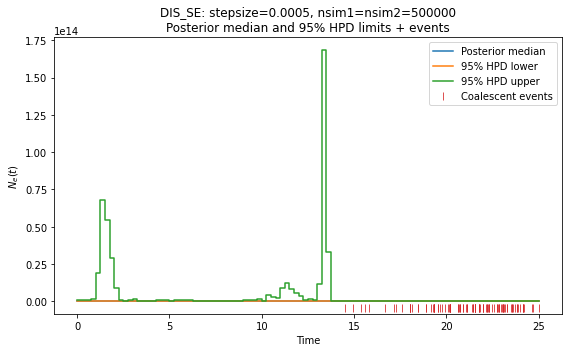


DIS_SE: stepsize=0.001, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_0.001_nsim1_500000_nsim2_500000.npz


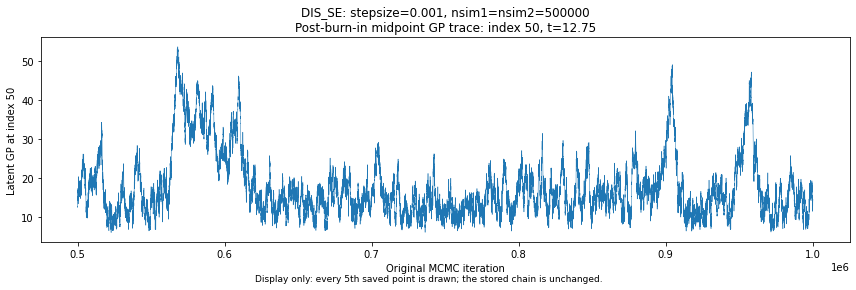

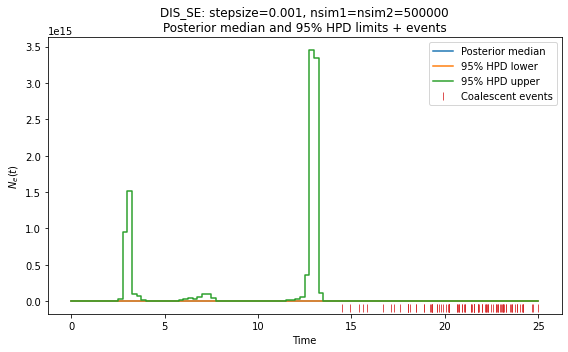


DIS_SE: stepsize=0.005, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_0.005_nsim1_500000_nsim2_500000.npz


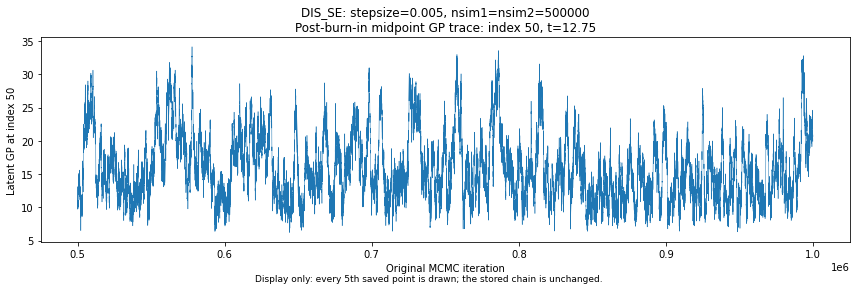

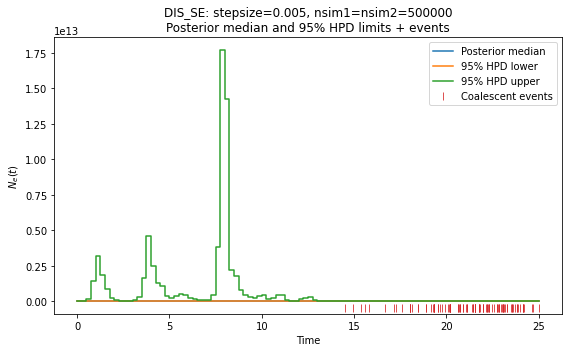


DIS_SE: stepsize=0.05, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_0.05_nsim1_500000_nsim2_500000.npz


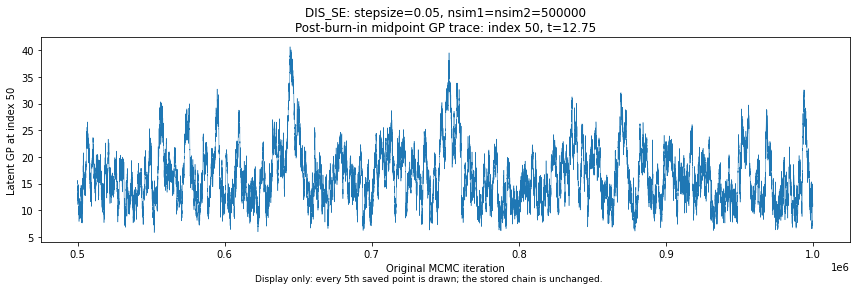

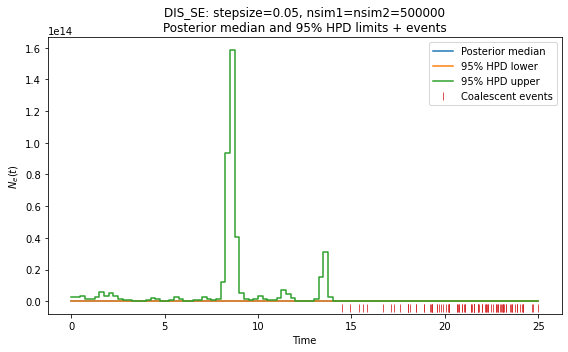


DIS_SE: stepsize=0.01, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_0.01_nsim1_500000_nsim2_500000.npz


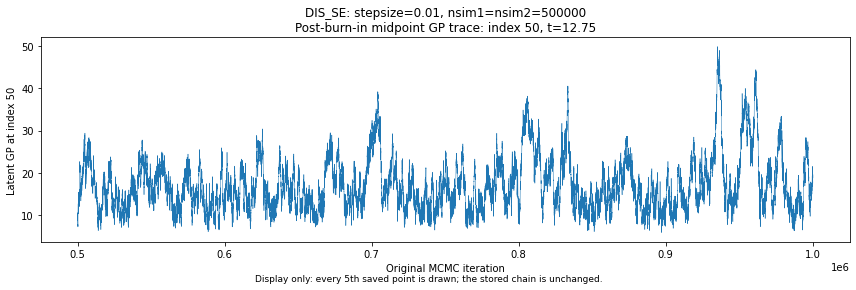

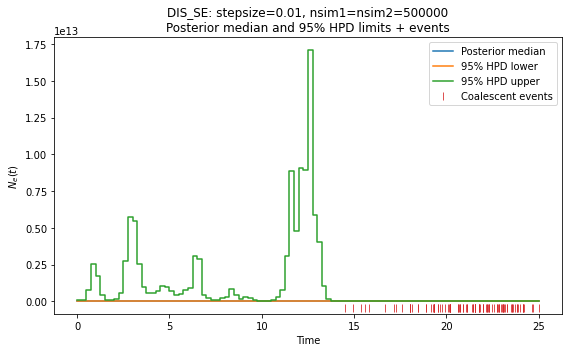


DIS_SE: stepsize=0.1, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_0.1_nsim1_500000_nsim2_500000.npz


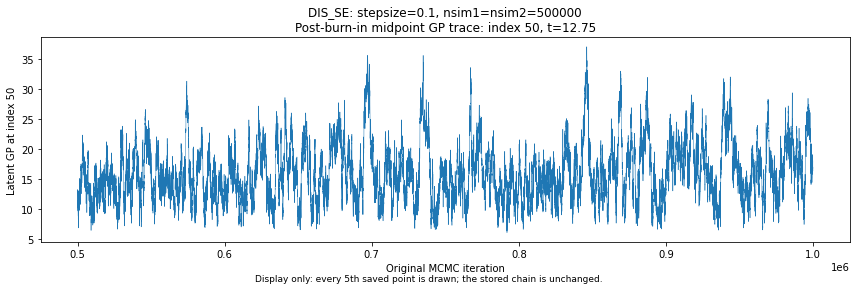

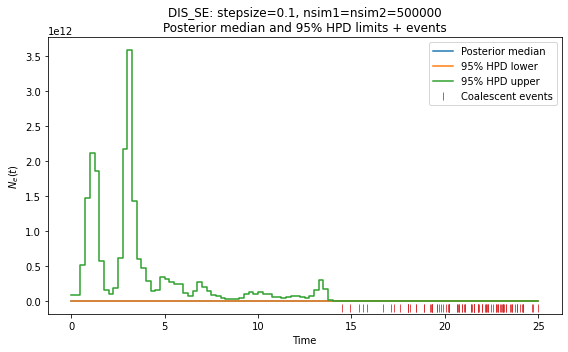


DIS_SE: stepsize=0.15, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_0.15_nsim1_500000_nsim2_500000.npz


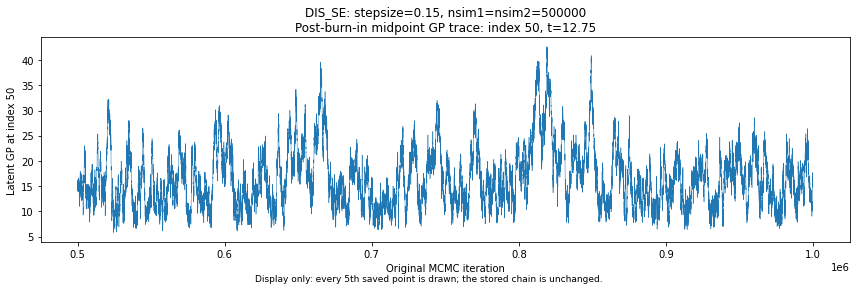

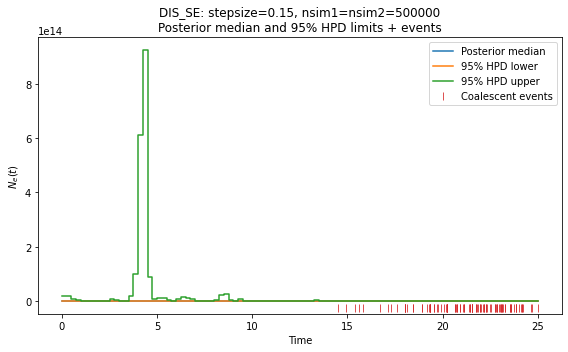


DIS_SE: stepsize=0.2, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_0.2_nsim1_500000_nsim2_500000.npz


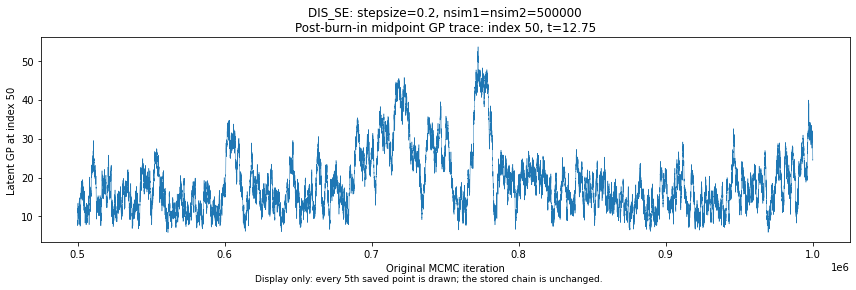

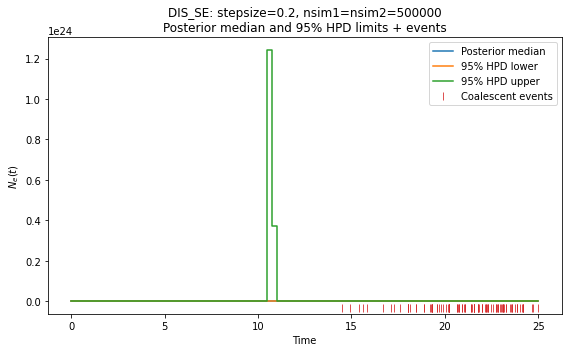


DIS_SE: stepsize=0.3, nsim1=nsim2=500000
[historical output directory]/real100_SE_DIS_stepsize_0.3_nsim1_500000_nsim2_500000.npz


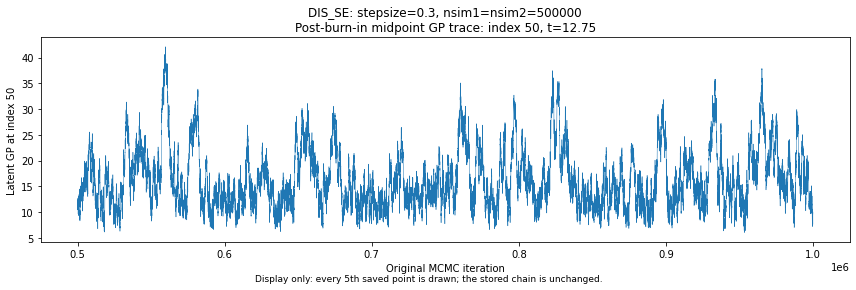

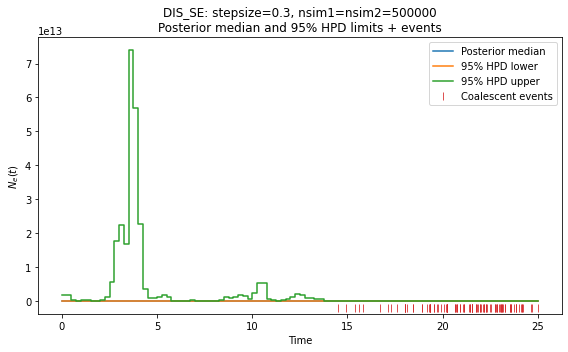


Missing DIS-SE settings:
[]


In [9]:
missing_DIS_SE = []

for nsim in SE_NSIM_VALUES:
    for proposal in SE_PROPOSAL_VALUES:
        ok = plot_one_setting(
            "DIS_SE",
            proposal=proposal,
            nsim=nsim,
        )
        if not ok:
            missing_DIS_SE.append((proposal, nsim))

print("\nMissing DIS-SE settings:")
print(missing_DIS_SE)


## Overall missing-file summary

In [ ]:
print("RI-BM missing :", len(missing_RI_BM))
print("DIS-BM missing:", len(missing_DIS_BM))
print("RI-SE missing :", len(missing_RI_SE))
print("DIS-SE missing:", len(missing_DIS_SE))

print("\nRI-BM:", missing_RI_BM)
print("\nDIS-BM:", missing_DIS_BM)
print("\nRI-SE:", missing_RI_SE)
print("\nDIS-SE:", missing_DIS_SE)
